# Gemma 4 Fine-Tuning (w/ First Pass Summary Training & Second Pass Distillation)


# Setup

In [ ]:
import datasets
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import re
import random
from google.colab import drive, userdata
from huggingface_hub import login, hf_hub_download
from pprint import pprint

cache_path = "/content/huggingface_cache"
os.makedirs(cache_path, exist_ok=True)
os.environ['HF_HOME'] = cache_path

if userdata.get('HF_TOKEN'):
  login(token=userdata.get('HF_TOKEN'))
  hf_hub_download(repo_id="sookiemonster/asrs-narratives", filename="utils.py", repo_type="dataset",local_dir=".")
  hf_hub_download(repo_id="sookiemonster/asrs-narratives", filename="synopses.csv", repo_type="dataset",local_dir=".")

raw_dataset = datasets.load_dataset("sookiemonster/asrs-narratives")
train_ds = datasets.load_dataset("sookiemonster/asrs-narratives-rebalance", split='train')
synopses = pd.read_csv("synopses.csv").set_index('acn')

utils.py: 0.00B [00:00, ?B/s]

synopses.csv: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/9.74M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/4.09M [00:00<?, ?B/s]

...

data/validation-00000-of-00001.parquet:   0%|          | 0.00/4.09M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.38M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/22992 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4441 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9868 [00:00<?, ? examples/s]

In [ ]:
valid_ds = raw_dataset['validation']
test_ds = raw_dataset['test']

labels = train_ds.features['label'].names

id_to_label = { idx : label for idx, label in enumerate(labels) }
label_to_id = { label : idx for idx, label in id_to_label.items() }

In [ ]:
from functools import partial

def filter_labels(ds, to_remove:list):
  to_remove_set = set(to_remove)
  return ds.filter(lambda example : id_to_label[example['label']] not in to_remove_set)

filter_ambiguous = partial(filter_labels, to_remove=['ambiguous'])

filtered_train_ds = filter_ambiguous(train_ds)
filtered_valid_ds = filter_ambiguous(valid_ds)

Filter:   0%|          | 0/22992 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4441 [00:00<?, ? examples/s]

In [ ]:
def _validate_groupings(groupings:dict[str, set]):
  mut_excl = [va.isdisjoint(vb) for ka, va in groupings.items() for kb, vb in groupings.items() if ka != kb]
  assert all(mut_excl), f"{mut_excl}"

  all_labels = set([label for val_set in groupings.values() for label in val_set])
  assert all_labels == set(id_to_label.values()), f"Missing: {set(id_to_label.values()) - all_labels}"


def group_labels(ds, groupings:dict[str, set]):
  _validate_groupings(groupings)
  group_names = list(groupings.keys())
  group_names.sort()

  fine_grained_label_to_group = {
      label : group_name for group_name, val_set in groupings.items() for label in val_set
  }

  res = ds.map(lambda ex: {"group" : fine_grained_label_to_group[ id_to_label[ex['label']] ]})
  res = res.filter(lambda ex: ex["group"] != 'DELETE')

  new_features = res.features.copy()
  group_names.remove("DELETE")
  new_features["group"] = ClassLabel(names=group_names)

  res = res.cast(new_features)
  return res

In [ ]:
from datasets import ClassLabel

groupings = {
    'DELETE' : set(['ambiguous']),
} | {
    label : set([label]) for label in labels if label != 'ambiguous'
}

grouped_ds_train = group_labels(filtered_train_ds, groupings)
grouped_ds_valid = group_labels(filtered_valid_ds, groupings)

Map:   0%|          | 0/22157 [00:00<?, ? examples/s]

Filter:   0%|          | 0/22157 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/22157 [00:00<?, ? examples/s]

Map:   0%|          | 0/4083 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4083 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4083 [00:00<?, ? examples/s]

In [ ]:
id_to_group = { i: group for i, group in enumerate(grouped_ds_train.features['group'].names) }
id_to_group

{0: 'aircraft',
 1: 'airport',
 2: 'airspacestructure',
 3: 'atcequipment/navfacility/buildings',
 4: 'chartorpublication',
 5: 'companypolicy',
 6: 'environment-nonweatherrelated',
 7: 'equipment/tooling',
 8: 'humanfactors',
 9: 'incorrect/notinstalled/unavailablepart',
 10: 'logbookentry',
 11: 'manuals',
 12: 'mel',
 13: 'procedure',
 14: 'softwareandautomation',
 15: 'staffing',
 16: 'weather'}

In [ ]:
id_to_logical = {
    0: 'Aircraft',
    1: 'Airport',
    2: 'Airspace Structure',
    3: 'ATC Equipment, Navigation Facility, or Buildings',
    4: 'Chart or Publication',
    5: 'Company Policy',
    6: 'Non-Weather-Related Environment',
    7: 'Equipment or Tooling',
    8: 'Human Factors',
    9: 'Incorrect, Not Installed, or Unavailable Part',
    10: 'Logbook Entry',
    11: 'Manuals',
    12: 'Minimum Equipment List (MEL)',
    13: 'Procedure',
    14: 'Software and Automation',
    15: 'Staffing',
    16: 'Weather'
}

# Distillation Setup

In [ ]:
# Remove anything that's already been used
distil_ds = datasets.load_dataset("sookiemonster/asrs-procedure-human-factor-fine-tune", split='train')
distil_acns = set(distil_ds.to_pandas()['acn'])

new_train_ds = grouped_ds_train.filter(lambda row : row['acn'] not in distil_acns)

README.md:   0%|          | 0.00/376 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/501k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/384 [00:00<?, ? examples/s]

Filter:   0%|          | 0/22157 [00:00<?, ? examples/s]

In [ ]:
shuffled_ds = new_train_ds.shuffle(seed=42)
df = shuffled_ds.to_pandas().set_index('acn').drop('label', axis=1)

df.group = df.group.map(id_to_group)
display(df['group'].value_counts(normalize=True))
df = df.rename(columns={'group' : 'primary_problem'})
display(df.head(2))

# batch_size = 20
# for i in range(0, len(df), batch_size):
#   df.iloc[i: min(i+batch_size, len(df))].to_csv(f"small_train_{i:04}.csv")

,proportion
group,
procedure,0.250298
humanfactors,0.246212
aircraft,0.159519
weather,0.080402
companypolicy,0.058821
environment-nonweatherrelated,0.051566
chartorpublication,0.032188
airspacestructure,0.030489
atcequipment/navfacility/buildings,0.027643


,text,primary_problem
acn,,
1713990,Narrative 1 - 'Descending on the [arrival] int...,weather
2207046,Narrative 1 - 'On Day 0; I was aboard a single...,aircraft


In [ ]:
summarized = df.join(synopses, how='inner').drop('text', axis=1)
summarized

,primary_problem,Report_1_Synopsis
acn,,
1713990,weather,Flight Crew reported a go around due to tail w...
2207046,aircraft,Pilot reported during cruise the engine began ...
1992258,aircraft,B737 Captain reported aircraft rapidly pitched...
1903474,humanfactors,Air Carrier ramp personnel reported he failed ...
2006539,humanfactors,A320 Captain reported a new hire pilot failed ...
...,...,...
1646912,companypolicy,Aircraft Maintenance Technician reported a fli...
2027838,aircraft,Air carrier pilots reported during climb the E...
2005348,aircraft,Air carrier flight crew reported a loss of dir...


In [ ]:
classes = ['humanfactors', 'procedure', 'aircraft', 'weather']
li = []
for c in classes:
  temp = summarized[summarized.primary_problem == c]
  temp.to_csv(f"training_{c}_synopses.csv")
  li.append(temp)

In [ ]:
li[3]

,primary_problem,Report_1_Synopsis
acn,,
1713990,weather,Flight Crew reported a go around due to tail w...
2227760,weather,B787 First Officer reported experiencing mount...
1725216,weather,Air Carrier Captain reported fatigue after a c...
1709335,weather,C172 flight instructor reported severe mountai...
1270491,weather,ZMA Controllers report of aircraft deviations ...
...,...,...
2152199,weather,Air carrier Captain reported a wind shear and ...
1282147,weather,A B737 crew on the ATL WARRR1 RNAV STAR were d...
1274967,weather,Houston TRACON (I90) reports of having to vect...


# System Prompt: Aviation Incident Classification
**Role:** You are an expert Aviation Safety Analyst specializing in Root Cause Analysis (RCA). Your objective is to generate rationales for existing classifications of report narratives by using the attached reference sheet's category definitions, repeated issues associated with each label and disambiguation matrix. If the reference sheet's definitions (repeated issues & disambiguation matrix) does not accommodate the existing classification label, briefly explain how to add to the reference sheet a **separate code block BEFORE the JSON** and then output the JSON object using the updated reference information. NEVER modify the existing label, only the logic in the reference.

---

### Required Output Format
For each incident report provided, output the following JSON:
{
  "acn" : <the unique report number corresponding to the incident>,
  "summary" : <a concise 2-3 sentence summary detailing the sequence of events in the incident>,
  "primary_problem" : <the existing label for the incident>,
  "rationale" : <explain the classification in 4 sentences, and strictly why it is not a similar class. >
}

You are already supplied with the text, acn report number, and primary problem. Do not change them. Use them exactly as they are supplied. You are only responsible for providing a 2-3 sentence incident summary and rationale behind why the incident's primary problem was the provided label and why it does _not_ belong to a similar class.

You MUST use the entire text from each narrative, do not use a subset or substring.

Now provide the JSON and potential updates for each of the TEN attached incidents.

## Changes:
### Aircraft
- **Electrical & Avionics Failures** — Complete electrical failures (loss of GPS, ADS-B, radios), faulty alternators, erroneous EICAS/ECAM messages, fire loops, **or hardware-induced false EGPWS/GPWS alerts.**

### ACNS to note:
- 2264541: Aircraft, but could be an ATC or procedural error...
- 2244237: Airport
- 1586550: Env-Nonweather but is about being insulted and getting overwhelmed because of it

In [ ]:
df.loc[2264541]['text']

'Narrative 1 - \'We were cleared to line up and wait on Rwy 3R for departure after the traffic on final".  There was Aircraft Z on approximately 3 mile final we saw visually and on TCAS.   Person A though this clearance seemed very nonstandard we accepted and lined up after the traffic landed.  We cleared visually and on TCAS and didn\'t see any other aircraft for 3R.While we were waiting to get takeoff clearance; I noticed another aircraft behind and above us on TCAS while we were on the runway awaiting takeoff clearance.  The tower controller was speaking Spanish so I couldn\'t understand what was said but the TCAS traffic was Aircraft Y that executed a go around at approximately 700 feet and overflew us in the takeoff position.  Nothing was said to us and after the go around Aircraft Y was clear we were cleared for takeoff without any comment or incident. I am confident we complied with the Towers instructions and were not at fault at all; but it is unsafe to issue clearances onto r

In [ ]:
synopses.loc[2264541]['Report_1_Synopsis']

'Air Carrier Captain reported they were on the runway in position and holding when an arriving aircraft on short final executed a go around and overflew them.'

In [ ]:
df.loc[2244237]['text'] # labeled ATC

"Narrative 1 - 'GPS overhead light illuminated; transponder fail light and GPS-L invalid message in FMC over a restricted area. Executed the QRH procedure and informed ATC. ATC verified that they were receiving ADS-B signal and transponder information. Aircraft navigation was accurate on one GPS.ATC relayed that the restricted area was conducting tests. GPS light extinguished after about 30 minutes. Inertial Reference System (IRS) light illuminated on recall before descent. Wrote up discrepancy in the logbook. Cause: ATC update NOTAMs or sector broadcast live testing.'"

In [ ]:
synopses.loc[2244237]['Report_1_Synopsis']

'B737-800 pilot flying reported losing one GPS for thirty minutes during cruise due to testing that was occurring in the area.'

In [ ]:
df.loc[1586550]['primary_problem'], df.loc[1586550]['text']

('environment-nonweatherrelated',
 "Narrative 1 - 'This is a new type of safety issue for me; but I felt compelled to report it to have more eyes review the information. I had Aircraft X; a VFR; call up for flight following from within my area. The pilot had a strong accent; and that along with what I suspect was the quality of his radio made it very hard for me to understand his transmissions. I also had some distraction from within the TRACON itself; which I will describe in a moment. It probably took me over 10 transmissions to get Aircraft X pilot's intentions; and successfully get him processed for flight following. He had also requested an IFR clearance; but after I informed him his requested altitude of 020 was likely to cause issues with MVA's and the subsequent Center sector; he elected to maintain VFR with flight following. There were multiple SIGMETs from all over Texas; and the weather at ZZZ was IFR; information I gave the pilot. I had Aircraft Y being vectored for an RNAV

In [ ]:
synopses.loc[1586550]['Report_1_Synopsis']

'TRACON Controller reported an unsafe operation along with pressure induced by a relieving controller.'

## Get Mini-Batch of Samples

In [ ]:
# Get the first K instances corresponding to each label
first_k = 100

# Separate into CSVs of <batch_size> instances
batch_size = 10

for g in id_to_group.values():
  selected = df[df.primary_problem == g].head(first_k)

  for i in range(0, first_k, batch_size):
    batch = selected.iloc[i: i + batch_size]
    batch.to_csv(f"train_{g.replace("/", "").replace("-", "")}_{i}-{i+batch_size}.csv")

In [ ]:
processed =[
    ['train_aircraft_0-10' , 'yes'],
    ['train_aircraft_10-20' , 'yes'],
    ['train_airspace_0-10' , 'yes'],
    ['train_airspace_10-20' , 'yes'],
    ['train_airport_0-10' , 'yes'],
    ['train_airport_10-20' , 'yes'],
    ['train_atcnavfacility_0-10' , 'yes'],
    ['train_atcnavfacility_10-20' , 'yes'],
    ['train_companypolicy_0-10' , 'yes'],
    ['train_companypolicy_10-20' , 'yes'],
    ['train_chartorpublication_0-10' , 'yes'],
    ['train_chartorpublication_10-20' , 'yes'],
    ['train_equipmenttooling_0-10' , 'yes'],
    ['train_equipmenttooling_10-20' , 'yes'],
    ['train_nonweather_0-10' , 'yes'],
    ['train_nonweather_10-20' , 'yes'],
    ['train_mel_0-10' , 'yes'],
    ['train_mel_10-20' , 'yes'],
    ['train_manuals_0-10' , 'yes'],
    ['train_manuals_10-20' , 'yes'],
    ['train_logbookentry_0-10' , 'yes'],
    ['train_logbookentry_10-20' , 'yes'],
]

In [ ]:
from glob import glob

li = []
distil_files = glob("*.json")
for fname in distil_files:
  li.append(pd.read_json(fname))

distil_df = pd.concat(li).set_index('acn')

In [ ]:
distil_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, 1872703 to 1598686
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   summary          219 non-null    object
 1   primary_problem  219 non-null    object
 2   rationale        219 non-null    object
dtypes: object(3)
memory usage: 6.8+ KB


In [ ]:
distil_df.index.nunique()

219

In [ ]:
distil_df.primary_problem.value_counts()

,count
primary_problem,
aircraft,20
airspacestructure,20
airport,20
mel,20
logbookentry,20
equipment/tooling,20
environment-nonweatherrelated,20
companypolicy,20
chartorpublication,20


In [ ]:
train_df = grouped_ds_train.to_pandas().set_index('acn')
train_df.drop('label', inplace=True, axis=1)
train_df.group = train_df.group.map(id_to_group)

joined = distil_df.join(train_df)

In [ ]:
joined[joined.group != joined.primary_problem]

,summary,primary_problem,rationale,text,group
acn,,,,,
1770479,During routine ADS-B testing of a grounded hel...,atcequipmentnavfacilitybuildings,This is classified as ATC Equipment / Nav Faci...,Narrative 1 - 'A rotorcraft was in a all metal...,atcequipment/navfacility/buildings
1335729,"While in cruise flight, a flight crew received...",atcequipmentnavfacilitybuildings,The ATC Equipment / Nav Facility / Buildings c...,Narrative 1 - 'During cruise flight at FL370 w...,atcequipment/navfacility/buildings
1298211,A controller reported that the FUSION radar sy...,atcequipmentnavfacilitybuildings,This report is classified as ATC Equipment / N...,Narrative 1 - 'The controller received multipl...,atcequipment/navfacility/buildings
1292549,A controller was unable to track an IFR aircra...,atcequipmentnavfacilitybuildings,This fits ATC Equipment / Nav Facility / Build...,Narrative 1 - 'The BFL radar equipment could n...,atcequipment/navfacility/buildings
2244237,"While flying over a restricted area, an aircra...",atcequipmentnavfacilitybuildings,"Based on the updated reference guide logic, th...",Narrative 1 - 'GPS overhead light illuminated;...,atcequipment/navfacility/buildings
1612878,An air traffic controller attempted to resolve...,atcequipmentnavfacilitybuildings,This is classified as ATC Equipment / Nav Faci...,Narrative 1 - 'I was working the combined high...,atcequipment/navfacility/buildings
1359117,"While holding short of a runway, multiple flig...",atcequipmentnavfacilitybuildings,The ATC Equipment / Nav Facility / Buildings l...,Narrative 1 - 'We were told by ground to pull ...,atcequipment/navfacility/buildings
1771218,"During a visual approach, an aircraft's autopi...",atcequipmentnavfacilitybuildings,This incident is classified as ATC Equipment /...,Narrative 1 - 'Visual Approach with both autop...,atcequipment/navfacility/buildings
1602878,A local controller observed a false target on ...,atcequipmentnavfacilitybuildings,This is classified as ATC Equipment / Nav Faci...,Narrative 1 - 'While working the Local Control...,atcequipment/navfacility/buildings


In [ ]:
joined.primary_problem = joined.primary_problem.replace('atcequipmentnavfacilitybuildings', 'atcequipment/navfacility/buildings')

In [ ]:
joined.to_csv("distillation_train.csv")

# Next Steps
1. Fine-tune on entire training set using synopses. (i.e. summarize this narrative)
2. Fine-tune on the distilled data.


# Phase 1) Summary Tuning

## Setup/Upload Training Dataset

In [ ]:
train_df = grouped_ds_train.to_pandas().set_index('acn')
train_df.drop('label', inplace=True, axis=1)
train_df.group = train_df.group.map(id_to_logical)
train_and_synopses = train_df.join(synopses)
train_and_synopses.rename({'Report_1_Synopsis' : 'summary'}, inplace=True, axis=1)
train_and_synopses

,text,group,summary
acn,,,
2008766,Narrative 1 - 'I was working ZZZ and North arr...,Weather,A TRACON Controller reported aircraft on appro...
2109432,Narrative 1 - 'Wheelchair battery form and pro...,Human Factors,Air carrier Captain reported the Ramp Agent ga...
1974739,Narrative 1 - 'The aircraft at some point in t...,Human Factors,BE35 pilot reported loss of oil pressure in fl...
1904026,Narrative 1 - 'My FO deadheaded into ZZZ and w...,Aircraft,B767 Captain reported a gate return due to exc...
1787366,Narrative 1 - 'Upon reaching clearance for ILS...,Aircraft,C172 flight instructor reported a complete fai...
...,...,...,...
1269926,Narrative 1 - '[We] received a call from [oper...,Company Policy,Ramp worker reported a 'significant weight shi...
1537257,Narrative 1 - 'I was performing the duties of ...,Procedure,ERJ-175 First Officer reported N90 TRACON requ...
1481252,Narrative 1 - 'While working traffic; I notice...,Procedure,ZLA Center controller reported they received a...


In [ ]:
str(list(id_to_logical.values()))

"['Aircraft', 'Airport', 'Airspace Structure', 'ATC Equipment, Navigation Facility, or Buildings', 'Chart or Publication', 'Company Policy', 'Non-Weather-Related Environment', 'Equipment or Tooling', 'Human Factors', 'Incorrect, Not Installed, or Unavailable Part', 'Logbook Entry', 'Manuals', 'Minimum Equipment List (MEL)', 'Procedure', 'Software and Automation', 'Staffing', 'Weather']"

In [ ]:
def row_to_answer(row):
  return json.dumps({
      'acn' : str(row.name),
      'summary' : row.summary,
      'primary_problem' : row.group,
  })

def message_to_example(row):
  possible_categories = list(id_to_logical.values())
  sys_prompt = f'You are an expert Aviation Safety Analyst classifying incidents based on the most relevant and underlying primary problem. You must assign them exactly one of the following categories: {possible_categories}'

  template = "Classify this aviation incident report. Return your answer as a JSON object specifying the report's ACN, a brief summary of the incident, and the primary problem:\n[ACN: {acn}]\n{text}"
  prompt = template.format(acn=row.name, text=row['text'])

  messages = []
  messages.append({
      'role' :'system',
      'content' : [{ 'type' : "text", 'text' : sys_prompt }]
  })
  messages.append({
      'role' :'user',
      'content' : [{ 'type' : "text", 'text' : prompt }]
  })
  messages.append({
      'role' :'assistant',
      'content' : [{ 'type' : "text", 'text' : row_to_answer(row) }]
  })

  return messages

pprint(message_to_example(train_and_synopses.iloc[0]))

[{'content': [{'text': 'You are an expert Aviation Safety Analyst classifying '
                       'incidents based on the most relevant and underlying '
                       'primary problem. You must assign them exactly one of '
                       "the following categories: ['Aircraft', 'Airport', "
                       "'Airspace Structure', 'ATC Equipment, Navigation "
                       "Facility, or Buildings', 'Chart or Publication', "
                       "'Company Policy', 'Non-Weather-Related Environment', "
                       "'Equipment or Tooling', 'Human Factors', 'Incorrect, "
                       "Not Installed, or Unavailable Part', 'Logbook Entry', "
                       "'Manuals', 'Minimum Equipment List (MEL)', "
                       "'Procedure', 'Software and Automation', 'Staffing', "
                       "'Weather']",
               'type': 'text'}],
  'role': 'system'},
 {'content': [{'text': 'Classify this aviation incident repor

In [ ]:
from datasets import Dataset

def make_dataset(df:pd.DataFrame, first_k: int):
  res = pd.DataFrame(df.apply(lambda r : message_to_example(r), axis=1), columns=['messages'])
  res['primary_problem'] = df.group
  res = res.sample(frac=1, random_state=42).groupby('primary_problem').head(first_k)
  ds = Dataset.from_pandas(res)
  return ds

ds = make_dataset(train_and_synopses, 1_000)
ds

Dataset({
    features: ['messages', 'primary_problem', 'acn'],
    num_rows: 9336
})

In [ ]:
ds.to_pandas()['primary_problem'].value_counts()

,count
primary_problem,
Weather,1000
Human Factors,1000
Company Policy,1000
Procedure,1000
Aircraft,1000
Non-Weather-Related Environment,1000
Chart or Publication,701
Airspace Structure,664
"ATC Equipment, Navigation Facility, or Buildings",602


In [ ]:
ds.push_to_hub("sookiemonster/asrs-synopses-pre-training-random-1000")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  58%|#####8    | 6.22MB / 10.7MB            

README.md:   0%|          | 0.00/425 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/sookiemonster/asrs-synopses-pre-training-random-1000/commit/617ceab5041ada5a5a7ace2e0ba833cb40c6b722', commit_message='Upload dataset', commit_description='', oid='617ceab5041ada5a5a7ace2e0ba833cb40c6b722', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sookiemonster/asrs-synopses-pre-training-random-1000', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sookiemonster/asrs-synopses-pre-training-random-1000'), pr_revision=None, pr_num=None)

## Load Dataset & Train

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers peft accelerate bitsandbytes trl
# %%capture
# import os, re
# if "COLAB_" not in "".join(os.environ.keys()):
#     !pip install unsloth
# else:
#     import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
#     xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
#     !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
#     !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
# !pip install --no-deps transformers==5.5.0
# !pip install torchcodec
# import torch; torch._dynamo.config.recompile_limit = 64;

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-skxqd74d/unsloth_765a6490b09b4a69aaecd2e70c4f7cf5
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-skxqd74d/unsloth_765a6490b09b4a69aaecd2e70c4f7cf5
  Resolved https://github.com/unslothai/unsloth.git to commit df3a205726d231bd12402960a3cd3a90b85c7fc7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 159.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 133.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.7 MB/s eta 0:00:0

In [ ]:
from datasets import load_dataset

ft_dataset = load_dataset("sookiemonster/asrs-synopses-pre-training-random-1000", split='train')

README.md:   0%|          | 0.00/499 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/10.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9336 [00:00<?, ? examples/s]

In [ ]:
ft_dataset[0]['messages']

[{'content': [{'text': "You are an expert Aviation Safety Analyst classifying incidents based on the most relevant and underlying primary problem. You must assign them exactly one of the following categories: ['Aircraft', 'Airport', 'Airspace Structure', 'ATC Equipment, Navigation Facility, or Buildings', 'Chart or Publication', 'Company Policy', 'Non-Weather-Related Environment', 'Equipment or Tooling', 'Human Factors', 'Incorrect, Not Installed, or Unavailable Part', 'Logbook Entry', 'Manuals', 'Minimum Equipment List (MEL)', 'Procedure', 'Software and Automation', 'Staffing', 'Weather']",
    'type': 'text'}],
  'role': 'system'},
 {'content': [{'text': "Classify this aviation incident report. Return your answer as a JSON object specifying the report's ACN, a brief summary of the incident, and the primary problem:\n[ACN: 1554409]\nNarrative 1 - 'While proceeding to ZZZ and deviating around thunderstorms near the ZZZZZ Intersection; we received significant reroute instructions from A

In [ ]:
from unsloth import FastLanguageModel, FastModel
import torch

model_id = "unsloth/gemma-4-E2B-it"
model, tokenizer = FastLanguageModel.from_pretrained(
    model_id,
    load_in_4bit = True,
    dtype = torch.bfloat16,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

In [ ]:
# As per https://unsloth.ai/docs/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
# As per: https://unsloth.ai/docs/models/gemma-4/train#quickstart

peft_model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False, # Turn off for just text!
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,

    r = 16,
    lora_alpha = 32,
    lora_dropout = 0,

    bias = "none",
    random_state = 42,

    use_gradient_checkpoint='unsloth',
    use_rslora = True,               # We support rank stabilized LoRA
    loftq_config = None,               # And LoftQ
)

In [ ]:
from unsloth import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    "gemma-4"
)

In [ ]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
    return { "text" : texts, }

formatted_train = ft_dataset.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/9336 [00:00<?, ? examples/s]

In [ ]:
formatted_train['text'][8]

'<bos><|turn>system\n[{\'text\': "You are an expert Aviation Safety Analyst classifying incidents based on the most relevant and underlying primary problem. You must assign them exactly one of the following categories: [\'Aircraft\', \'Airport\', \'Airspace Structure\', \'ATC Equipment, Navigation Facility, or Buildings\', \'Chart or Publication\', \'Company Policy\', \'Non-Weather-Related Environment\', \'Equipment or Tooling\', \'Human Factors\', \'Incorrect, Not Installed, or Unavailable Part\', \'Logbook Entry\', \'Manuals\', \'Minimum Equipment List (MEL)\', \'Procedure\', \'Software and Automation\', \'Staffing\', \'Weather\']", \'type\': \'text\'}]<turn|>\n<|turn>user\nClassify this aviation incident report. Return your answer as a JSON object specifying the report\'s ACN, a brief summary of the incident, and the primary problem:\n[ACN: 1762776]\nNarrative 1 - \'Upon arrival in ZZZ on Flight AB; fleet wanted to immediately board the aircraft without regard to social distancing. 

### Trial 1) Linear & 2e-5

In [ ]:
from transformers import DataCollatorForSeq2Seq
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = peft_model,
    train_dataset = formatted_train,
    tokenizer = tokenizer,

    args = SFTConfig(
        dataset_text_field = "text",
        bf16 = True,
        fp16 = False,

        max_grad_norm = 0.3,
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 2,

        warmup_steps = 20,
        num_train_epochs = 1,
        learning_rate = 2e-5,

        logging_steps = 1,

        save_strategy = "steps",
        optim = "adamw_8bit",
        lr_scheduler_type = "linear",
        weight_decay = 0.01,

        seed = 42,
        output_dir = "./outputs",
        report_to = "none",
    )
)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/9336 [00:00<?, ? examples/s]

In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,336 | Num Epochs = 1 | Total steps = 1,167
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 25,337,856 of 5,148,515,872 (0.49% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,15.110638
2,14.915750
3,14.688114
4,14.864328
5,14.259020
6,13.338364
7,12.620830
8,11.938023
9,11.161444
10,10.270935


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-500/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1167/tokenizer_config.json.


In [ ]:
from google.colab import drive, userdata

repo_id = "sookiemonster/gemma-4-asrs-summarization-rand-1000"
peft_model.push_to_hub(repo_id, token=userdata.get('HF_TOKEN'))
tokenizer.push_to_hub(repo_id, token=userdata.get('HF_TOKEN'))

README.md:   0%|          | 0.00/575 [00:00<?, ?B/s]

NotImplementedError: 

### Re-tune Hyperparameters

In [ ]:
from transformers import DataCollatorForSeq2Seq
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = peft_model,
    train_dataset = formatted_train,
    tokenizer = tokenizer,

    args = SFTConfig(
        dataset_text_field = "text",
        bf16 = True,
        fp16 = False,

        max_grad_norm = 0.3,
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 2,

        warmup_steps = 20,
        num_train_epochs = 1,
        learning_rate = 1e-4,

        logging_steps = 1,

        save_strategy = "steps",
        optim = "adamw_8bit",
        lr_scheduler_type = "cosine",
        weight_decay = 0.01,

        seed = 42,
        output_dir = "./outputs",
        report_to = "none",
    )
)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/9336 [00:00<?, ? examples/s]

In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,336 | Num Epochs = 1 | Total steps = 1,167
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 25,337,856 of 5,148,515,872 (0.49% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,15.110638
2,14.915750
3,14.074808
4,12.900242
5,10.964868
6,9.639152
7,8.668513
8,7.962581
9,7.585669
10,7.114658


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-500/tokenizer_config.json.


Step,Training Loss
1,15.110638
2,14.915750
3,14.074808
4,12.900242
5,10.964868
6,9.639152
7,8.668513
8,7.962581
9,7.585669
10,7.114658


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1000/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-1167/tokenizer_config.json.


In [ ]:
from google.colab import drive, userdata

repo_id = "sookiemonster/gemma-4-asrs-summarization-rand-1000-cosine"
peft_model.push_to_hub(repo_id, token=userdata.get('HF_TOKEN'))
tokenizer.push_to_hub(repo_id, token=userdata.get('HF_TOKEN'))

README.md:   0%|          | 0.00/575 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|          |  559kB /  101MB            

Saved model to https://huggingface.co/sookiemonster/gemma-4-asrs-summarization-rand-1000-cosine


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpwj_k1rqb/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpwj_k1rqb/tokenizer.json: 100%|##########| 32.2MB / 32.2MB            

# Phase 2) Distillation Tuning

## Setup/Upload Dataset

### Load CSV

In [ ]:
example_df = pd.read_csv("distillation_train.csv", index_col=[0]).drop('group', axis=1)
example_df.head(2)

,summary,primary_problem,rationale,text
acn,,,,
1872703,The flight crew experienced an uncommanded ear...,aircraft,This incident is classified as aircraft becaus...,Narrative 1 - 'FMS/FMC/Autopilot Failure. I lo...
1814136,"While relocating an airplane, the pilot experi...",aircraft,The classification of aircraft is appropriate ...,Narrative 1 - 'I was taking delivery of an air...


In [ ]:
train_df = grouped_ds_train.to_pandas().set_index('acn')
train_df.drop('label', inplace=True, axis=1)
logical_groups = train_df.group.map(id_to_logical)

train_examples = example_df.join(logical_groups)
train_examples = train_examples.drop('primary_problem', axis=1)
train_examples.head(2)

,summary,rationale,text,group
acn,,,,
1872703,The flight crew experienced an uncommanded ear...,This incident is classified as aircraft becaus...,Narrative 1 - 'FMS/FMC/Autopilot Failure. I lo...,Aircraft
1814136,"While relocating an airplane, the pilot experi...",The classification of aircraft is appropriate ...,Narrative 1 - 'I was taking delivery of an air...,Aircraft


In [ ]:
train_examples['rationale'].iloc[0]

'This incident is classified as aircraft because the root cause was a mechanical or systems failure within the flight control and automation systems[cite: 1, 2]. Specifically, the autopilot initiated an uncommanded descent before intercepting the glide slope, which aligns with the "Flight Control & Automation Malfunctions" repeating issue for this category[cite: 1]. It is not classified as Procedure because there is no indication that the crew improperly configured the FMS or ignored SOPs; rather, the system acted without being prompted[cite: 1]. Furthermore, it is distinct from Software and Automation as the narrative points to a general system malfunction requiring a physical maintenance write-up rather than a specific database or software programming error[cite: 2].'

### Run Top-K Predictions

In [ ]:
import torch
import sys

print(f"Python Version: {sys.version_info.major}.{sys.version_info.minor}")
print(f"PyTorch Version: {torch.__version__.split('+')[0]}")
print(f"CUDA Version (Torch): {torch.version.cuda}")
print(f"CXX11 ABI: {torch._C._GLIBCXX_USE_CXX11_ABI}")

Python Version: 3.12
PyTorch Version: 2.10.0
CUDA Version (Torch): 12.8
CXX11 ABI: True


In [ ]:
!pip install "https://github.com/lesj0610/flash-attention/releases/download/v2.8.3-cu12-torch2.10-cp312/flash_attn-2.8.3%2Bcu12torch2.10cxx11abiTRUE-cp312-cp312-linux_x86_64.whl"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.6/253.6 MB 4.5 MB/s eta 0:00:00


In [ ]:
from transformers import pipeline

tuned_model = "sookiemonster/asrs-modernbert-rebalance-weighted"
pipe = pipeline('text-classification', tuned_model, dtype=torch.bfloat16, device="cuda", top_k=5)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/299M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
texts = list(train_examples['text'])
display(pd.Series(texts[:5]))

,0
0,Narrative 1 - 'FMS/FMC/Autopilot Failure. I lo...
1,Narrative 1 - 'I was taking delivery of an air...
2,Narrative 1 - 'Enroute ZZZ-ZZZ1; Divert to ZZZ...
3,Narrative 1 - 'During cruise; a steady Stab Ou...
4,Narrative 1 - 'Configured on final and receive...


In [ ]:
raw_predictions = pipe(texts)
raw_predictions[:5]

W0428 13:38:21.763000 3276 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


[[{'label': 'aircraft', 'score': 0.45765867829322815},
  {'label': 'softwareandautomation', 'score': 0.252743124961853},
  {'label': 'humanfactors', 'score': 0.1509198099374771},
  {'label': 'atcequipment/navfacility/buildings',
   'score': 0.05818477272987366},
  {'label': 'environment-nonweatherrelated', 'score': 0.030661221593618393}],
 [{'label': 'aircraft', 'score': 0.9422457814216614},
  {'label': 'humanfactors', 'score': 0.0382881797850132},
  {'label': 'weather', 'score': 0.006058069411665201},
  {'label': 'procedure', 'score': 0.003972978796809912},
  {'label': 'environment-nonweatherrelated', 'score': 0.002861629007384181}],
 [{'label': 'aircraft', 'score': 0.8041291832923889},
  {'label': 'humanfactors', 'score': 0.0747956708073616},
  {'label': 'weather', 'score': 0.06498360633850098},
  {'label': 'environment-nonweatherrelated', 'score': 0.01905963011085987},
  {'label': 'procedure', 'score': 0.018473226577043533}],
 [{'label': 'mel', 'score': 0.534800112247467},
  {'label

In [ ]:
import json

with open("train_top_5_predictions.json", "w") as f:
  json.dump(raw_predictions, f)

### Append Top-K Predictions

In [ ]:
top_k = None
with open("train_top_5_predictions.json", "r") as f:
  top_k = json.load(f)

top_k[:5]

[[{'label': 'aircraft', 'score': 0.45765867829322815},
  {'label': 'softwareandautomation', 'score': 0.252743124961853},
  {'label': 'humanfactors', 'score': 0.1509198099374771},
  {'label': 'atcequipment/navfacility/buildings',
   'score': 0.05818477272987366},
  {'label': 'environment-nonweatherrelated', 'score': 0.030661221593618393}],
 [{'label': 'aircraft', 'score': 0.9422457814216614},
  {'label': 'humanfactors', 'score': 0.0382881797850132},
  {'label': 'weather', 'score': 0.006058069411665201},
  {'label': 'procedure', 'score': 0.003972978796809912},
  {'label': 'environment-nonweatherrelated', 'score': 0.002861629007384181}],
 [{'label': 'aircraft', 'score': 0.8041291832923889},
  {'label': 'humanfactors', 'score': 0.0747956708073616},
  {'label': 'weather', 'score': 0.06498360633850098},
  {'label': 'environment-nonweatherrelated', 'score': 0.01905963011085987},
  {'label': 'procedure', 'score': 0.018473226577043533}],
 [{'label': 'mel', 'score': 0.534800112247467},
  {'label

In [ ]:
flat_top_5 = pd.Series([[item['label'] for item in sublist] for sublist in top_k])
flat_top_5[:2]

,0
0,"[aircraft, softwareandautomation, humanfactors..."
1,"[aircraft, humanfactors, weather, procedure, e..."


In [ ]:
flat_top_5.index = train_examples.index
train_examples['top_5'] = flat_top_5
train_examples.head(2)

,summary,rationale,text,group,top_5
acn,,,,,
1872703,The flight crew experienced an uncommanded ear...,This incident is classified as aircraft becaus...,Narrative 1 - 'FMS/FMC/Autopilot Failure. I lo...,Aircraft,"[aircraft, softwareandautomation, humanfactors..."
1814136,"While relocating an airplane, the pilot experi...",The classification of aircraft is appropriate ...,Narrative 1 - 'I was taking delivery of an air...,Aircraft,"[aircraft, humanfactors, weather, procedure, e..."


### Remove Gemini Citations

In [ ]:
cite_pattern = r'\[cite:\s*\d+(?:\s*,\s*\d+)*\]'

search = lambda text : set(re.findall(cite_pattern, text))
display(train_examples['rationale'].map(search).value_counts())
display(train_examples['summary'].map(search).value_counts())

,count
rationale,
{},209
"{[cite: 6], [cite: 6, 11], [cite: 10]}",1
"{[cite: 1, 2], [cite: 2], [cite: 1]}",1
"{[cite: 15, 16], [cite: 12], [cite: 12, 17]}",1
"{[cite: 18, 27], [cite: 18, 19], [cite: 18], [cite: 23, 31]}",1
"{[cite: 38, 39], [cite: 40, 51], [cite: 38, 40, 51], [cite: 45, 46, 47]}",1
{[cite: 37]},1
"{[cite: 61, 73], [cite: 61, 63], [cite: 61], [cite: 61, 71, 75]}",1
"{[cite: 79, 81], [cite: 78, 83], [cite: 78], [cite: 78, 80]}",1


,count
summary,
{},209
"{[cite: 6], [cite: 6, 11], [cite: 9, 10]}",1
"{[cite: 2, 4], [cite: 1, 3], [cite: 1]}",1
"{[cite: 12, 14, 15, 16], [cite: 12]}",1
"{[cite: 20, 23], [cite: 21, 22, 27], [cite: 18, 31]}",1
"{[cite: 45, 46, 48], [cite: 38, 40], [cite: 51, 52, 55]}",1
{[cite: 37]},1
"{[cite: 72, 73], [cite: 63, 65, 69, 71], [cite: 58, 59, 61]}",1
"{[cite: 79, 80], [cite: 78], [cite: 80, 82]}",1


In [ ]:
def strip_citations(raw_df):
  df = raw_df.copy()
  remove_citations = lambda text : re.sub(cite_pattern, '', text)
  df['rationale'] = df['rationale'].map(remove_citations)
  df['summary'] = df['summary'].map(remove_citations)
  return df

no_cites = strip_citations(train_examples)
no_cites.head(1)

,summary,rationale,text,group,top_5
acn,,,,,
1872703,The flight crew experienced an uncommanded ear...,This incident is classified as aircraft becaus...,Narrative 1 - 'FMS/FMC/Autopilot Failure. I lo...,Aircraft,"[aircraft, softwareandautomation, humanfactors..."


In [ ]:
tt = no_cites.summary.str.contains('cite')
tt[tt == True]

,summary
acn,
1454649,True


In [ ]:
tt = no_cites.rationale.str.contains('cite')
tt[tt == True]

,rationale
acn,


In [ ]:
no_cites.loc[1454649].summary

"A TRACON controller experienced a loss of separation between an arriving and a departing aircraft because an adjacent Center sector failed to climb the departure. The controller cited excessive coordination demands and confusion surrounding the facility's Letter of Agreement (LOA) as primary contributors to the breakdown."

In [ ]:
no_cites.head()

,summary,rationale,text,group,top_5
acn,,,,,
1872703,The flight crew experienced an uncommanded ear...,This incident is classified as aircraft becaus...,Narrative 1 - 'FMS/FMC/Autopilot Failure. I lo...,Aircraft,"[aircraft, softwareandautomation, humanfactors..."
1814136,"While relocating an airplane, the pilot experi...",The classification of aircraft is appropriate ...,Narrative 1 - 'I was taking delivery of an air...,Aircraft,"[aircraft, humanfactors, weather, procedure, e..."
2111776,"While enroute at 40,000 feet, the aircraft los...",This event perfectly aligns with the aircraft ...,Narrative 1 - 'Enroute ZZZ-ZZZ1; Divert to ZZZ...,Aircraft,"[aircraft, humanfactors, weather, environment-..."
1912278,"During cruise flight, the crew received a stea...",The aircraft classification is assigned becaus...,Narrative 1 - 'During cruise; a steady Stab Ou...,Aircraft,"[mel, aircraft, softwareandautomation, atcequi..."
1979148,"While configuring on short final, the crew rec...",This report is classified as aircraft because ...,Narrative 1 - 'Configured on final and receive...,Aircraft,"[procedure, environment-nonweatherrelated, air..."


### Setup Reference Sheet

In [ ]:
label_inventory_intro = """# Aviation Incident Classification Reference Guide

## Label Inventory & Classification Cues

---"""

company_policy = """### `Company Policy`

Reports where an **organizational decision, management directive, scheduling practice, regulatory/procedural policy gap, or systematic pressure from company or ATC management** is the root cause.

**Repeating issues:**

- **Management pressure to fly/accept unairworthy aircraft** — captains pressured to accept aircraft with known defects, fuel leaks, inoperative APUs, or chronic maintenance issues; management reassigning refused aircraft to another crew; supervisors overriding captain refusals; this is one of the most frequent patterns in this label
- **Traffic Management Unit (TMU) management failures** — TMU/Command Center refusing to implement flow control during known weather events; cancelling flow programs prematurely; overriding safety-based ATC requests; forcing aircraft through weather; not acting on overloaded sectors — a very prominent sub-theme for ATC reporters
- **Crew fatigue and scheduling** — pilots and flight attendants calling in fatigued; schedules pushing legal FAR 117 rest limits; excessive duty time; schedule changing report times in computer to obscure violations; pressure to accept flight duty period extensions
- **ATC management decisions overriding safety** — supervisors approving altitudes below MVA; management assigning non-certified supervisors to work sectors; refusing sector flow management despite requests
- **Ramp and ground crew non-compliance / company pressure on ground ops** — ground crews not following pushback procedures; ramp agents not following DG handling rules; management not enforcing safety zones; rampers pressured to load without sufficient crew
- **COVID-19 operational impacts** — mask non-compliance by passengers (and management not enforcing policy), controller distraction from mask wearing, tower closures due to COVID, vaccine mandate stress and safety concerns, inadequate exposure notification to employees, social distancing enforcement gaps
- **DG (Dangerous Goods) and Hazmat policy violations** — improperly loaded hazmat under company direction; FOM providing no guidance to flight crews on DG; companies refusing to report certain maintenance issues involving DG; live animals loaded without confirmation of adequate conditions
- **Company operational practices creating safety hazards** — servicing emergency exit slides with passengers on board; company terminating real-time weather access in favor of inferior systems; inadequate aircraft configuration for required crew (e.g., insufficient jumpseats for aft flight attendants); iPads as primary chart source but charging cords not tracked as maintenance equipment; company requiring non-standard procedures (releasing brakes before push clearance)
- **Company pressure on maintenance** — management instructing technicians not to write up discrepancies; pressuring maintenance to ignore manual procedures; accomplishing tasks in unsafe environments; allowing known-defective parts to remain in service; confidentiality breaches about safety findings
- **Dispatch-level policy issues** — dispatcher overridden by supervisor who dispatched a refused flight; inadequate fuel policy; company policy restricting approach options with no weather alternatives; improper or invalid routings continuously filed for specific routes
- **Instructional / Flight School Policies** — Flight instructor intervention protocols, curriculum design, or teaching philosophies that inherently create safety hazards (e.g., intentionally allowing a student to deviate significantly on an IFR clearance to "teach a lesson").
- **Corporate Communication & Equipage Policies** — Airline management policies that dictate inefficient or hazardous communication flows (e.g., forcing the flight deck to act as a primary medical relay station due to a lack of cabin SATCOM).
- **Dispatch & Trip Support Policies** — Company administrative failures in providing international flight crews with necessary passenger documentation or verifying regulatory requirements prior to dispatch.
- **Standard Operating Procedure (SOP) Design Flaws** — Company-mandated flight deck procedures or checklists that inherently reduce safety margins (e.g., forcing heads-down FMC inputs during active taxi to prioritize fuel savings over situational awareness).
- **Occupational Health & Workplace Safety Policies** — Management failing to enforce health mandates, directing crews to work alongside toxic chemicals or open fuel tanks, or actively denying contract workers direct access to safety reporting systems.
- **Customer Interfacing & Privacy Policies** — Lack of clear corporate guidance for crew members regarding passenger conduct, such as ambiguity on how to handle passengers filming the crew during security disturbances.
- **Operational Control Conflicts** — Systemic organizational issues where station operations or gate agents are structurally permitted to usurp legal Dispatch authority regarding flight delays and turnaround times.
- **Facility Infrastructure Policies (Airline-side)** — The airline's failure to provide adequate administrative or flight planning facilities at out-stations, systemically disincentivizing proper dispatch briefings.

**Key signals in text:** "pressure," "refused aircraft," "management," "company policy," "fatigue," "scheduling," "legal rest," "dispatch," "TMU," "flow control," "traffic management," "COVID," "DG cargo," "MEL" (when management overrides refusal), "on time," "cancellation," "vaccine mandate," "ETOPS," "unsafe\""""

environment_non_weather = """### `Environment - Non Weather Related`

Reports where an **external environmental factor** (not weather, not a structural airspace or chart issue) affected operations. This is a broad catch-all for non-meteorological external hazards.

**Repeating issues:**

- **Bird/Foreign Animal strikes** — strikes on approach, departure, or ground; damage to AOA vanes, engines, windshields, hydraulic systems; bird/eagle ingestion on takeoff roll causing rejected takeoff; bird strikes triggering compressor stalls; geese/birds on runway; post-landing damage found at destination
- **UAV/Drone encounters** — near misses with unmanned aircraft near departure/arrival airports; drones sighted in Class B airspace; UAS observed flying unsafely near manned aircraft; controller reports of UAS in controlled airspace without authorization
- **GPS jamming / spoofing** — GPS signal loss attributed to deliberate interference (military testing, foreign airspace — particularly DXB, Manila, oceanic areas); GNSS NOT AVAILABLE messages; GPS not recovering after exiting jamming area; ATC noting aircraft in wrong airspace due to limited nav capability
- **5G interference** — RA faults on approach, GPS loss at specific airports attributed to 5G towers; FMS anomalies attributed to 5G during climbout; multiple reports from same geographic locations
- **Passenger misconduct** — non-compliance with face mask policy; non-compliance with social distancing seat policy; disruptive or threatening passengers prompting air return; unaccompanied minors refusing safety instructions; passengers refusing to move seats for safety purposes
- **Wake turbulence** — from a preceding aircraft encountered on approach, departure, cruise, or during ground taxi; flight attendant injuries from wake turbulence; go-arounds triggered by wake turbulence encounter
- **Wildlife on runways / taxiways** — dogs, deer, geese, and other wildlife on active runways or taxiways during takeoff or landing roll; wildlife taxi hazards at non-towered airports
- **Distraction from ground-based lighting** — illuminated billboards adjacent to approach ends of runways distracting during night/IMC approaches; strobe lights from ground events distracting on short final
- **Balloon and aerial obstacle encounters** — balloon strikes on power lines; near misses with balloons during climb; skydiver near-miss conflicts with aircraft
- **Overheating / fire from passenger electronics** — overheating cell phone chargers in cabin; iPad battery smoke/fumes; passenger electronic device fires requiring diversion; contained fires from e-cigarettes
- **COVID-19 protocol conflicts** — COVID-related impacts that are environmental rather than policy-driven (e.g., complacency from lack of recent flying cited for altitude deviations; COVID ATC center closure causing airspace violations)
- **Communication blackouts from external factors** — missed ATC frequency change due to poor radio coverage in geographic area; aircraft not handed off to next center; loss of communications in oceanic area with no backup systems
- **General NMAC events** — near mid-air collisions not clearly attributable to airspace design, ATC error, or other specific label; evasive action taken for NORDO traffic; NMACs in uncontrolled traffic patterns
- **Biological & Health Hazards (e.g., COVID-19)** — The ambient physical environment itself becomes a hazard due to extreme crowding, uncontrollable passenger volume, or lack of physical barriers during a biological crisis/pandemic.
- **External Obstacles & Terrain** — Unanticipated physical encounters with local topography (e.g., hills triggering early radio altimeter callouts) or transient mobile obstacles (e.g., catering trucks) encroaching on an active path.
- **Ambient Airspace Saturation** — The operational environment becomes completely unmanageable or chaotic due to external systemic disturbances, such as widespread military GPS jamming that forces rapid, chaotic clearance changes.

**Key signals in text:** "bird strike," "UAV," "drone," "GPS jamming," "5G," "spoofing," "passenger misconduct," "wildlife," "wake turbulence" (as event cause, not structural), "GNSS," "face mask," "GPS interference," "balloon," "skydiver," "billboard," "complacency," "lack of recent flying\""""

chart_or_publication = """### `Chart Or Publication`

Reports where an **error, ambiguity, outdated information, or missing content in a published aviation chart, airport diagram, NOTAM, navigation database, or other aviation publication** caused or contributed to the incident. Distinct from `Manuals` (which covers operational manuals, checklists, LOAs, AMMs).

**Repeating issues:**

- **Confusingly similar fix/waypoint names** — similarly spelled or sounding fixes on approaches/STARs/SIDs causing crew to load or fly the wrong fix; ATC and crew confusion from phonetically identical waypoints (e.g., CATTS/KATTS, LYNDE/LYNDI, SERFR STAR fixes, DRAKE VOR Arizona vs. DRAKE fix Colorado); read-back errors going uncaught because both fixes exist; this is very frequent
- **Outdated or incorrect airport diagrams** — taxiway charts not updated after construction; new taxiways not depicted; incorrect taxiway labeling; island features in deice pads not on any diagram; runway shortening not reflected; temporary taxiways uncharted
- **Incorrect or missing SID/STAR information** — missing or ambiguous engine-out procedures for departures; conflicting crossing restrictions; STAR transitions creating conflicts with stabilized approach criteria; noise abatement departure tracks diverging from published chart
- **NOTAM issues** — incomplete or omitted NOTAMs for taxiway/runway closures; NOTAM language unclear or indecipherable; TFR format/depiction confusing pilots and causing inadvertent violations; NOTAMs contradicting chart data; no NOTAM for PAPI/VASI that charts show as present but are absent; closures not in ATIS and not in NOTAM
- **Electronic Flight Bag / app charting errors** — Jeppesen FD Pro or FliteDeck Pro showing outdated layouts; RNAV approach not loadable by expected designation; chart inset information layout causing misreads; EFB display showing incomplete procedure due to incomplete display settings; DEN Tower frequency discrepancy between chart providers; approach charting errors in FD Pro for FIR boundaries
- **Navigation database errors** — FMS database missing fixes or having incorrect data; approach in FMC database that doesn't match the Jepp published procedure; preferred approach not in FMC database; STAR not loaded in FMS
- **Weight/clearance limits not charted** — taxiways with wingspan restrictions not prominently marked; incorrect weight limits for taxiways; pavement near runway lacking markings or designation; runway available from takeoff data message not reflecting new taxiway designation
- **Vital information inconspicuously presented** — critical chart directives (e.g., altitude requirements) in marginal or non-prominent positions requiring scrolling on EFB; visual approach charts where path brings aircraft dangerously close to terrain without clear warning; speed restriction notes on arrival pages not noticed by multiple crews; company charts not highlighting mandatory visual approach criteria
- **Uncoordinated / Premature Publications** — Frequencies or procedures published on charts for public use before the corresponding ATC facility has been briefed, equipped, or authorized to use them.
- **Omitted Hazard Warnings** — Known, chronic environmental or structural hazards (e.g., bridge-like runways prone to freezing) lacking required safety warnings or notes on the official approach/airport charts.
- **Confusing Layouts & Formatting** — Charts, dispatch releases, or performance data publications that are technically correct but utilize poor formatting, small fonts, confusing verbiage, or bury critical information on obscure pages, directly inducing crew errors.
- **Missing Identifiers & Visual References** — Airport diagrams or approach charts completely missing taxiway names, failing to depict taxiway geometry, or inaccurately depicting the physical location of visual aids (e.g., PAPI lights).
- **Incomplete Database Updates** — EFB charts, FMS databases, or moving maps failing to reflect permanent NOTAM changes or structural updates, showing conflicting data across different pages of the same provider.

**Key signals in text:** "chart," "publication," "airport diagram," "NOTAM," "FMS database," "similar sounding," "similar fix," "incorrectly depicted," "FliteDeck," "Jeppesen," "taxi instructions did not correlate," "outdated," "not charted," "not depicted," "TFR," "frequency discrepancy," "engine-out procedure," "database\""""

airspace_structure = """### `Airspace Structure`

Reports where **the design, structure, boundaries, or configuration of airspace** — including conflicting routes, inadequate separation standards, class designations, or poorly designed procedures — contributed to the incident. Focus is on the _structure_ itself, not on equipment failure or individual human error.

**Repeating issues:**

- **TCAS / Resolution Advisory (RA) events** — RA issued due to conflicting traffic in structurally problematic airspace; crew complying with RA resulting in low altitude alert; parallel runway approaches with RA; RA triggered by VFR aircraft structurally in conflict with IFR routes
- **MVA / Minimum Vectoring Altitude violations** — aircraft descending below MVA due to ATC vectors dictated by SID/STAR structure or airspace design; low altitude alerts issued; controllers vectoring into unlabeled MVA areas; MVA labeling on displays insufficient
- **VFR/IFR conflicts from airspace design** — VFR aircraft operating undetected beneath or near Class B/C Bravo; VFR departures from satellite airports structurally conflicting with IFR final approach courses of adjacent airport; recommendation for Class B/C upgrade to resolve chronic conflict; non-towered airports with intersecting runways where no communication standard exists
- **Similarly named fixes causing routing errors** — confusion between nearly identical sounding waypoints leading to course deviations (distinct from Chart label: here the _airspace routing_ creates the conflict, not just the chart depiction)
- **Airspace design issues at boundaries** — STAR placing aircraft in conflict with VFR practice areas; inadequate separation between satellite airport and main airport approach paths; sectors where arrival/departure split creates chronic conflicts; restricted/warning areas not reflected in information display systems; military aircraft deviating from authorized airspace into adjacent Class C
- **Traffic pattern conflicts / NMACs** — near mid-air collisions from poor traffic pattern design at non-towered airports; non-standard pattern entries creating conflicts; aircraft on converging courses at pattern altitude; helicopter/fixed-wing conflicts in pattern
- **UAV / UAS in controlled airspace** — UAV sighted after departure from major airports (LAX, LGA); UAS reports by controllers of unauthorized operations in controlled airspace creating conflicts with arriving/departing IFR traffic
- **TFR structure / special use airspace conflicts** — aircraft inadvertently entering TFRs due to unclear airspace boundaries; restricted area information removed from controller displays causing safety concerns; overlapping special use airspace scheduling conflicts
- **Speed violations in structured airspace** — aircraft exceeding 200 knots below Class B due to structural aspects of the arrival/departure procedure
- **Altitude deviations from structural handoff issues** — aircraft left on headings too long by design; descended through assigned altitude due to sector structure; controller training events resulting in MVA violations from sector design
- **Instrument Approach Procedure Design Flaws** — Erroneous vertical navigation (VNAV) paths or poorly designed RNAV/GPS lateral/vertical guidance that forces aircraft off a safe glidepath, where the procedure's structural design rather than a database corruption is the root cause.

**Key signals in text:** "TCAS RA," "resolution advisory," "MVA," "minimum vectoring altitude," "low altitude alert," "airspace design," "VFR/IFR conflict," "NMAC," "altitude deviation," "separation," "similar fix names," "Class B/C," "TFR," "restricted area," "pattern conflict," "UAV" (in controlled airspace context)\""""

atc_equipment = """### `ATC Equipment / Nav Facility / Buildings`

Reports where **ATC facility equipment, navigation aids, building infrastructure, or ARTCC/TRACON automation systems** malfunctioned or caused a safety issue. Focus is on physical/electronic equipment at the _facility_ level.

**Repeating issues:**

- **GPS jamming / GNSS outages** — GPS failure at specific geographic areas affecting multiple aircraft; ADS-B FAULT messages; GPS not available messages reported to ATC; oceanic areas with no radar/GPS backup systems; aircraft entering wrong airspace due to GPS failure
- **Frequency / radio outages** — recurring frequency outages at specific TRACONs/towers; limited radio coverage areas causing loss of communication; transmitter/receiver site failures that are known but unrepaired; bleed-over from adjacent frequencies causing communication confusion; monitor frequency for PRM approaches compromised by overlapping ATC communications; stuck microphones on ground control frequencies
- **ILS / glideslope anomalies** — false or unreliable glideslope signals; ILS glideslope not received until close to FAF (known problem at specific airports); flight director commanding wrong-direction turns at same airport repeatedly; PAPI misalignment; incorrect ILS identifier broadcast by airport; glideslope fluctuation causing confusing NOTAMs
- **ARTCC/TRACON automation failures** — Y90/N90 known automation problems causing airspace deviations; aircraft amended altitude/route reverting to original after handoff (ZFW); ERAM and STARS not interacting correctly with beacon codes; ATC computer route not updating correctly after amendment; automation-triggered sector conflicts; TRACON Controller noting automation issues affecting Providence Approach communication
- **Radar and display failures** — data tags dropping off display at specific airports (ORD ADSE/ASDE-X area); radar scope going blank; loss of radar and missing aircraft after feed switch; phantom primary targets on radar; ghost targets causing confusion; NCT TRACON Conflict Alert data blocks overlapping preventing proper separation
- **Runway Status Light malfunctions** — runway status lights illuminating red spuriously (IAH Runway 15R), causing rejected takeoffs; system malfunctioning to the "on" position and pilots being unaware lights are unreliable
- **ASDE-X / surface automation errors** — ASDE-X triggering go-arounds because helicopter not recognized by software; aircraft beacon codes not tagged correctly from neighboring facility
- **Building / facility infrastructure issues** — fire alarms going off periodically without cause (known recurring issue) distracting controllers; ATC tower layout blocking sightlines to movement areas; tower cannot see hold short markings; runway lighting timing out during critical phase; facility lacking runway lighting control
- **ATIS frequency conflicts** — multiple airports sharing same ATIS frequency; airport broadcasting incorrect ILS identifier on ATIS
- **HF/SATCOM and communication facility gaps** — communication issues departing oceanic airports; no backup systems for radar and communication sites in oceanic areas
- **Tower Cab Equipment Obstructions** — Physical placement of ATC tower equipment (e.g., radar display monitors, window frames) creating dangerous blind spots that physically obstruct the controller's view of active runways or taxiways.
- **Automated Weather System (ASOS/AWOS) Failures** — Ground-based automated weather stations broadcasting highly inaccurate visibility, ceiling, or wind data due to sensor malfunctions or poor placement.

**Key signals in text:** "GPS jamming," "frequency outage," "ILS," "glideslope," "PAPI," "localizer," "radio coverage," "ATC equipment," "facility," "ATIS," "navigation facility," "false signal," "bleed-over," "automation," "data tag," "radar scope," "runway status light," "ASDE-X," "ERAM," "STARS," "transmitter," "phantom target\""""

equipment_tooling = """### `Equipment / Tooling`

Reports where **ground support equipment, maintenance tooling, ramp equipment, dispatch hardware/software, or onboard non-avionics equipment** malfunctioned or was used incorrectly. Broader than just ramp equipment — includes any physical tool or device used in operations that is not a core aircraft avionics system.

**Repeating issues:**

- **Tow bar failures** — shear pin breaks; tow bar damage to nose gear; aircraft disconnecting from tow bar during pushback; wrong tow bar used for aircraft type (crew asked to abort engine start due to incorrect tow bar); tow bar becoming disconnected causing uncommanded aircraft movement
- **Tug / pushback vehicle malfunctions** — tug steering failures (drive-by-wire tug losing all steering due to computer); brake failures on tugs; tug "bucking" or lurching; aircraft rolling free after tug separation; ramp tractor brakes failing while approaching aircraft causing damage
- **Ground vehicle / equipment contact with aircraft** — baggage/cargo loaders striking aircraft; ground vehicles contacting aircraft during pushback; jetbridge overhang in safety zone creating collision hazard; jetbridge leveling system malfunctioning and sinking during deplaning; ground power cable hoist breaking and falling near ramp employees
- **LED lights on ground equipment blinding crew** — tugs equipped with LED headlights blinding flight crew during pushback, preventing them from seeing safety zone or marshaller
- **Jacking / maintenance equipment failures** — tail jack failing mid-operation causing aircraft tail to drop; incorrectly sized lift equipment
- **Airport / approach lighting failures (ramp/surface level)** — PAPI lights inoperative with no NOTAM; runway edge lights out; taxiway lighting failures; ramp area inadequately lit for safe equipment operation (collision in poorly lit area)
- **Communication equipment failures (ground)** — ground crew headset/communication equipment failure during pushback; stuck microphone in cockpit-cabin communication preventing normal operation requiring diversion; ACARS bleeding through active radio frequency; phone numbers for automated weather information inoperative
- **Dispatch / operations software and hardware** — dispatch computer system outages causing loss of operational control of airborne flights; dispatch program crashes during shift; flight tracking tool showing position off by large margin; ACARS working intermittently; Sabre flight planning software issuing unauthorized exemptions; computer-generated altitude below MEA going undetected; dispatcher software not accepting valid NAT altitude
- **iPad / EFB hardware failures** — iPad becoming unusable shortly after takeoff; iPad malfunctions during taxi; battery failure; EFB freezing on Jeppesen FliteDeck-Pro during approach; iPad mount lodged under pedals preventing braking; iPad download during taxi inhibiting chart access; magnetic iPad case potentially affecting compass; EFB mount interfering with control column movement; iPad window tray protruding into elbow space of pilot
- **Expired or defective onboard safety equipment** — expired fire extinguisher discovered when needed for in-flight fire; defective first aid equipment; flight attendant unable to log into electronic manual during medical emergency
- **Ground Support & Cabin Equipment (GSE) Failures** — Malfunctions or hazards involving non-aircraft physical equipment, such as broken jetbridges, ground power cable hoists, baggage belt loaders missing safety stops, or galley service carts with broken brakes.
- **Improvised or Inappropriate Servicing Tools** — The use of unauthorized or makeshift equipment (e.g., squeegees or helicopter rotor wash) to perform critical aircraft servicing like deicing due to the lack of proper airport tooling.
- **Aircraft Navigation Equipment Malfunctions** — Hardware-level failures or unexplained erroneous commands from aircraft navigation tools (e.g., Flight Directors or FMS equipment) that misguide the crew.
- **Electronic Flight Bag (EFB) & Dispatch Applications** — Software bugs, routing logic errors, or data-pull omissions within specific tooling applications (e.g., JeppFD-Pro recognizing a VOR as a heliport, SABRE dropping NOTAMs, PDC generation glitches) where the software acts as an operational tool.
- **Maintenance & Servicing Tooling** — Broken or improperly labeled maintenance gear, such as deteriorated ventilation hoses, empty calibration gas for detectors, or mispainted nitrogen/oxygen servicing bottles.
- **ATC & Ground Navigation Hardware** — Physical ATC hardware limitations (e.g., poor transmitter frequency coverage at low altitudes) or ground-based ILS equipment anomalies (e.g., ILS critical area interference) when treated generically as equipment deficiencies.
- **Auxiliary Aircraft Equipment (APU/ECS)** — Failures of auxiliary equipment, such as APU bleed air leaks causing cabin fumes, requiring the use of emergency oxygen tools.

**Key signals in text:** "tow bar," "tug," "pushback," "shear pin," "ground equipment," "baggage loader," "contact with aircraft," "jack," "ground power," "nose gear cradle," "ramp equipment," "dispatch software," "ACARS," "computer outage," "iPad," "EFB," "LED headlight," "jetbridge," "fire extinguisher," "communication equipment\""""

airport = """### `Airport`

Reports where **airport infrastructure, markings, lighting, layout, physical conditions, or the general operational environment of the airport surface** caused or contributed to a safety event. Distinct from ATC Equipment (which is about ATC facility systems) and Chart (which is about published information).

**Repeating issues:**

- **Faded or missing runway/taxiway markings** — centerline markings worn or inaccurate after construction; taxiway edge lines missing; hold-short lines unclear or confusingly placed (hold short line far back from runway entry); centerline markings on new taxiways not remaining clear of adjacent hold lines (DCA Taxiway J); lead-in lines incorrect
- **Poor airport lighting** — inadequate taxiway centerline lighting at night; poorly lit ramp areas causing equipment collisions; beacon too weak to see; gate equipment in inadequately lit hardstand areas; unlighted traffic cones for taxiway closures; ramp spot colors creating confusion; runway/taxiway lights not working at foreign airports
- **Confusing or absent signage** — missing taxiway signs making identification impossible (Taxiway Kilo not visible while on Bravo); ambiguous signage during construction (SBN Taxiway A3); taxiway designated on signage not matching charts (construction renaming); chart information conflicting with traffic pattern indicators (PCZ); missing markings at MYNN causing position confusion near runway
- **Ground vehicle conflicts** — vehicles crossing in front of taxiing aircraft; vehicles failing to yield to aircraft; ramp congestion with vehicles in safety zones; tug operator not using proper communications creating close contact with another aircraft during pushback; vehicle crossing runway on takeoff roll requiring crew to continue
- **FOD and surface condition** — loose asphalt causing propeller strikes; potholes on taxiways; loose concrete creating surface hazards; ice (black ice) on taxiways causing aircraft to slide after landing; jet blast blowing debris onto construction workers adjacent to taxiway; large bump on runway during takeoff roll not in NOTAMs
- **Construction zones without adequate notice** — active construction at runway end without NOTAM; repainted/relocated taxi lines without published changes; construction causing inaccurate and unclear taxi lines (ORD faded/inaccurate taxi lines at N/EE/LL); instrument and visual guidance not available due to frequent construction
- **Inadequate clearance / obstruction** — aircraft under tow turning onto already-occupied taxiway; helicopter crossing over wing during gate taxi; tree/tall vegetation around airport obstructing base and final for traffic pattern at non-towered airport creating NMAC risk; ground equipment (unlighted objects on a taxi line) in movement areas at night
- **PAPI / visual guidance errors** — PAPI guidance at specific runway resulting in aircraft crossing threshold too high; VASI charted but not installed with no plan to install; approach lighting systems released to maintenance and not repaired; PAPI lights inoperative with no NOTAM
- **Wildlife / animals on runways** — dogs, deer, geese on active runways during takeoff or landing roll; wildlife taxi hazards on taxiways
- **Non-towered airport hazards** — NMACs from non-communicating traffic at non-towered airports; aircraft not on CTAF; non-standard pattern entries disregarding position calls; IFR aircraft on approach without ATC notification on CTAF; conflicting chart/indicator information for traffic pattern direction
- **Non-standard traffic patterns / A/FD discrepancies** — Confusion, traffic conflicts, or airspace encroachments arising from non-standard airport traffic pattern altitudes or procedures specific to the local airport environment (e.g., A/FD stipulating an unexpected pattern altitude for turbine aircraft).
- **Airport Management / Publication Failures** — Airport authorities failing to issue required NOTAMs for preplanned runway/taxiway closures due to local policy, or failing to submit permanent physical airport changes (e.g., permanently closed runway sections) for chart updates over an extended period, creating a persistent mismatch between the physical airport and its documentation.
- **COVID-19 biological exposure events in ground operations** — Airport and airline
  agents working in high-volume, close-contact passenger environments without adequate
  physical protective infrastructure (e.g., no counter shields, insufficient distancing
  space, excessive passenger group sizes), where the external pathogen itself constitutes
  the primary environmental health hazard to operations personnel. Distinct from Company
  Policy in that the environmental exposure risk (pathogen + physical proximity) is the
  root hazard, even when understaffing or management inaction is a contributing factor;
  classify as Company Policy only when the report centers on a management directive or
  enforcement failure rather than on the physical exposure environment itself.

**Key signals in text:** "markings," "signage," "lighting," "ramp," "taxiway," "runway," "FOD," "construction," "ground vehicle," "airport condition," "pothole," "wing clearance," "beacon," "PAPI," "VASI," "non-towered," "black ice," "tree," "vegetation," "obscured," "taxi line\""""

staffing = """### `Staffing`

Reports where **insufficient personnel levels** — in ATC, airline operations, dispatch, maintenance, or ground handling — directly contributed to a safety event or unsafe condition. Distinct from `Company Policy` (which covers management _decisions_) — Staffing is about the _count of available personnel_ being the primary problem.

**Repeating issues:**

- **ATC understaffing / combined sectors** — controllers working multiple combined positions; local and ground positions merged; approach and departure combined; sectors exceeding MAP (Monitor Alert Parameter) limits; controllers refusing handoffs because receiving facility is overwhelmed; staffing attributed to COVID-19 causing many facilities to consolidate; Supervisor declining to call overtime resulting in unsafe combined positions
- **Workload-induced errors from understaffing** — controller not noticing conflict because working too many sectors; missed handoffs; VFR aircraft climbing through holding pattern altitude unnoticed; aircraft descending below MVA unnoticed; wrong aircraft given instruction due to attention split; loss of separation directly linked to staffing level
- **Tower closures** — towers closed part-time or fully due to staffing shortages; pilots unable to close IFR flight plans; ATC functions consolidated causing pilots to receive clearances different than filed; facilities not open during busy periods requiring TRACON to also cover tower work
- **Dispatcher overload** — dispatchers assigned too many flights simultaneously; surprise assignment of unfamiliar stations; high workload preventing proper flight planning support; insufficient staffing causing failure to advise flights about destination weather; dispatcher unable to maintain operational control of all assigned flights
- **Ramp / ground staffing** — only one wing walker present during pushback nearly causing collision; inadequate ramp personnel leading to DG cargo last-minute reconfiguration; ramp workers without adequate personnel to safely perform loading operations (no tail stand available); minimum crew requirements not maintained during aircraft search operations
- **ATC supervisor / manager gaps** — manager declining assist position requests; insufficient oversight of combined positions; Traffic Management Coordinators absent from shift; non-certified supervisor assigned to work sector during aircraft emergency; Operations Manager not aware of out-of-control situation in their area
- **Personnel not trained for required tasks** — no one available with training to accomplish required pitot static system drain line contamination removal; maintenance personnel lacking necessary equipment for deferred maintenance item; understaffed Airbus desk causing deferral of safety-critical items

**Key signals in text:** "staffing," "understaffed," "combined positions," "overloaded," "MAP," "COVID staffing," "workload," "overwhelmed," "short staffed," "working alone," "sole controller," "wing walker," "no assist," "overtime," "sectors combined," "too busy," "minimum crew\""""

manuals = """### `Manuals`

Reports where an **aviation manual, checklist, procedure document, Letter of Agreement (LOA), Aircraft Maintenance Manual (AMM), or similar operational reference document** was found to be incorrect, missing, conflicting, or inadequately written. Distinct from `Chart Or Publication` (navigation charts, NOTAMs, airport diagrams) and `MEL` (minimum equipment list specifically).

**Repeating issues:**

- **Conflicting procedures between manuals** — B737 NG vs. B737 MAX procedures in conflict; FOM vs. Ramp Operations Manual contradictions (dry ice and live animals in cargo); center vs. approach control LOA discrepancies; QRH vs. AFM disagreements; MEL not listed in dispatcher software, missing from flight release; DG quick reference manual vs. FOM conflict on measurement standards (18-inch clearance measured differently)
- **Missing procedures** — engine-out procedures absent from QRH (CE-560EP right engine starter); no QRH guidance for specific failure modes (Leading Edge Devices Not Extended); checklist items not included for newer aircraft differences; company not providing adequate materials forcing line pilots to improvise callouts and procedures; missing speed restriction note on arrival page missed by multiple crews simultaneously
- **Hazmat / DG documentation gaps** — battery-powered mobility device handling not in FOM with no flight crew guidance; incorrect DG loading guidance; FOM not providing adequate Hazmat handling instructions; battery-powered wheelchair documents containing errors and missing required labels; ambiguity about whether poisonous DG clearance from foodstuffs is 18 inches per which manual
- **Letter of Agreement (LOA) issues** — LOA between TRACON and Tower not being complied with (PHL); LOA revisions accidentally omitting previously approved coordination rules; facilities not briefed on changes; Tower not complying with ARTCC release amendment requirements; HCF TRACON LOA with OGG Tower creating burdensome workload increase; facility LOA with adjacent center resulting in conflicting clearance interpretations
- **Illustrated Parts Catalog (IPC) and AMM errors** — IPC listing incorrect parts; AMM not clear on when high-pressure turbine EGT inspection is required after exceedance; Structural Repair Manual with insufficient repair information requiring Engineering Authorization; procedural deficiency requiring EA; technicians spending excessive time researching correct part due to AMM complexity
- **Outdated manuals** — aircraft reconfigured but documentation not updated; old charts in EFB database; AFM referencing equipment not installed on aircraft; STAR/approach transitions not updated; FMC database out of date; company material disappearing from iPad when pilot attempted FOM update
- **Checklist errors** — QRH does not give clear direction for degraded engine; performance table errors in takeoff data; speed restriction information not prominent; incorrect or missing callout altitudes; checklist missing signature blocks for maintenance tasks (unclear who should sign)
- **Training material deficiencies** — inadequate documentation on new aircraft differences (B737 MAX switch function); poor training materials for new SOPs; Captain not given formal ground school for ETOPS before first ETOPS flight; captains in AQP oral finding many shortcomings in iPad replacement for traditional manuals; non-standard phraseology being used by instructors in training

**Key signals in text:** "manual," "checklist," "QRH," "AMM," "IPC," "LOA," "letter of agreement," "conflicting procedures," "missing procedure," "operations manual," "FOM," "flight manual," "publication error," "inadequate guidance," "contradicts," "no guidance," "not in the QRH," "improvise," "training material\""""

mel = """### `MEL`

Reports where a **Minimum Equipment List (MEL) item** — its application, interpretation, misapplication, physical compliance requirements, or adequacy — was the central issue. Distinct from general aircraft maintenance issues; the core problem is specifically about the MEL document, process, or deferral decision.

**Repeating issues:**

- **Misapplied or incorrectly applied MEL** — wrong MEL category applied to a discrepancy; aircraft flown in non-airworthy condition because MEL was applied incorrectly; MEL deferral on flight control computer performed incorrectly by maintenance; auto-spoilers MEL incorrectly applied triggered autobrakes warning causing RTO; A300 had flap problem and continued not in compliance with MEL
- **Ambiguous or unclear MEL language** — MEL text that is highly confusing, poorly worded, or fails to account for interconnected aircraft systems, resulting in crew distraction or maintenance misconfiguration. MEL wording open to interpretation; contradictory instructions within MEL; unclear requirements causing technician to defer multiple bleed valves on same engine; disagreement between technicians and inspectors on whether item within limits per MEL; MEL for A/C Pack operational status ambiguous when CFDS message displayed
- **MEL conflicts with other documents** — MEL contradicting QRH, PRC, AFM, or company operations manual; MEL fuel stick reference without including a fuel stick chart; MEL procedures for potable water system not in sync with operations; fuel quantity indicator MEL without adequate guidance for identifying fuel leak during flight
- **Incompatible dual deferrals** — two MELs applied to related systems creating combined non-airworthy state (bleed air insufficient for pressurization); GPS MEL not covering all FMC issues encountered; FMS on MEL with both FMS deferred making crew uncomfortable; ADC deferral changed to wrong system making SATCOM unusable
- **MEL for equipment not installed on specific variant** — MEL procedures listed for TKS deicing system not installed on that specific aircraft; MEL containing excessive data for unrelated conditions or other aircraft models; confusion distinguishing which MEL applies to which aircraft configuration
- **Physical inability to comply with MEL procedures** — crew cannot verify leading edge flap position in flight as MEL requires (cannot see from cockpit); crew cannot comply with MEL procedure due to design limitation
- **Captain refusal due to MEL concerns** — captain refusing aircraft due to inappropriate MEL; safety-compromising ETOPS MEL (inoperative APU for ETOPS); MEL used as chronic deferral mechanism for repeatedly written-up items (VOR written up 8 times in 10 days); captain refusing due to fuel quantity indicators on MEL with no reliable fuel leak detection
- **MEL exceeding deferral limits / unsafe deferral duration** — items deferred beyond allowed time; generator bearing annunciator deferred for 20-flight hours when bearing failed after only 3 hours causing electrical fire; EMB-145 fire extinguisher O-rings deferred via MEL without circuit breaker pulled, creating potential fire hazard
- **MEL administrative / paperwork errors** — MEL not noted in release documents; MEL overlooked and not discovered until after departure; maintenance release document not reflecting which A/C system is deferred; MEL item missing from dispatcher's software; incorrect MEL reference used
- **Dispatching in Violation of MEL** — Pressuring flight crews to accept aircraft that do not meet the restrictive conditions of an active MEL (e.g., fuel loaded in a tank that an MEL requires to be empty).
- **Operational Degradation due to MEL** — A legally deferred component (e.g., bleed air, ram air fan) creating severe secondary safety hazards, such as extreme cabin temperatures or unmanageable workload, forcing the crew to refuse the aircraft.
- **Failure to Apply or Document a Required MEL** — An aircraft is dispatched and flown with a known defect that legally requires an MEL deferral or verification flight, but the documentation process is completely omitted or bypassed.
- **Conflicting Placards & References** — The MEL's written instructions directly contradict physical warning placards installed on the aircraft (e.g., instructing inflight use of a ground-only deadbolt) or reference hidden/obscure manual pages, causing severe crew confusion regarding legal compliance.

**Key signals in text:** "MEL," "minimum equipment list," "deferred," "deferral," "dispatched with," "misapplied," "non-airworthy," "refusing aircraft due to MEL," "placard," "circuit breaker," "ETOPS MEL," "chronic deferral," "combined deferrals," "cannot comply," "not in compliance\""""

incorrect_part = """### `Incorrect / Not Installed / Unavailable Part`

Reports where a **wrong, missing, unapproved, or improperly installed part, component, or piece of equipment** created an airworthiness or safety issue. The physical component itself — not the documentation or MEL — is the problem.

**Repeating issues:**

- **Wrong part installed** — incorrect part number installed due to IPC error, distraction, manual misread, or verification failure; wrong tire/wheel assembly; incorrect fuel nozzles; wrong bearing; wrong fire seal; wrong O-ring installed on engine oil magnetic chip detector; incorrect windshield installed leading to inability to pressurize; technician misidentifying correct part due to bugs in computer program; incorrect part installed due to pressure from maintenance control
- **Missing hardware after maintenance** — missing fasteners (washers, bolts, screws) after tire/wheel changes; missing oil cap; missing gasket; missing bushing; missing safety wire; missing borescope plugs before flight (engine fire warning after takeoff); over-wing emergency slide panel with missing fasteners and some fasteners glued in place; carbon seal not installed causing engine oil loss and inflight shutdown
- **Maintenance omissions / not reinstalled** — Air Data Module not reinstalled after troubleshooting causing air turn back; borescope plug not installed; cannon plug not reconnected; oil line gasket not reinstalled; tail rotor gearbox oil cap not installed; hydraulic pump carbon seal not installed
- **Wrong data loaded in avionics** — FMC loaded with incorrect Airbus data instead of Boeing data; navigation database for wrong aircraft type loaded; incorrect aircraft performance data in FMS causing operational limitations
- **Life safety and emergency equipment issues** — life vests from retired aircraft installed; medical kit missing required contents (sealed kit with missing items); oxygen mask certified to wrong altitude; emergency slide lanyard incorrectly installed; flight attendant survival kit lanyard incorrectly installed; new seatbelts from removed seats reinstalled with new seats but not properly tightening; tray tables on backs of seats in emergency exit row; chart holders installed impeding window opening; EFB hard mount interfering with control column; EFB window tray protruding into pilot's elbow space
- **Bogus / recertified parts** — used consumable parts tested and re-certified using bogus procedures; "unserviceable" tags removed from tow bars and put back in service without repair; parts returned to service without proper qualification
- **Part number / catalog errors** — IPC listing incorrect parts with incorrect diagrams causing wrong part installation; harmonized part numbers causing test failures; conflicting information in IPC about which nose wheel assemblies authorized; engine fan blade annulus filler part number discrepancies; technician spending excessive time determining correct part
- **Pressure to install incorrect part** — management pressing technician to install incorrect part; pressure washer ordered made serviceable but still defective; replacement part unavailable leading to pressure to reinstall known inoperative part

**Key signals in text:** "incorrect part," "wrong part," "not installed," "missing," "not reinstalled," "improperly installed," "unavailable," "part number," "IPC," "preflight discovered," "airworthiness," "unapproved," "omitted," "overlooked during," "failed to install," "bogus\""""

logbook_entry = """### `Logbook Entry`

Reports where **aircraft maintenance record-keeping or logbook documentation** was the primary problem — entries missing, incorrect, unsigned, fraudulent, or otherwise non-compliant.

**Repeating issues:**

- **Undocumented/Missing entries** — maintenance performed without logbook entry; log pages not signed off before return to service; aircraft flew six flights with an open write-up; maintenance accomplished without entering in logbook; ceiling panel not in NEF deferral list discovered after takeoff; records check discovering unqualified technician performed tasks without entries
- **Missing signatures/unsigned/improperly signed logbooks** — logbook not signed off by maintenance; airworthiness release not signed; entry signed as complete when work was not done; annual signed off with missing paperwork for engine change; technician signed off entry requiring two technicians (electronic system allowing single sign-off); aircraft operation without all documents signed
- **Incorrect or erroneous entries** — erroneous entry due to fatigue or workload; entry for wrong system; logbook appeared to document prohibited actions by previous flight crew (water service door operation); logbook appeared to show maintenance write-up reported and deferred multiple times without resolution visible to captain
- **Ferry Permit issues** — aircraft operated on ferry flight without required Ferry Permit; pilot uncertain of currency for Part 91 flight after Part 121 operations
- **Suspected alteration / fraudulent records** — suspect alterations to aircraft, engine, and propeller logbooks discovered after alternator bearing failure in flight; maintenance signed as accomplished when work was not done
- **Airworthiness Directive and ETOPS documentation** — ETOPS pre-departure check finding lightning repairs not correctly recorded; aircraft struck by lightning with repairs not accomplished correctly or recorded; logbook and MEL confusion causing aircraft to fly with open item
- **Electronic logbook signing flaws** — system allowing sign-off of multi-technician required tasks by single technician; system accepting "Not Applicable" for required entries (overlaps with Software but documentation non-compliance is primary)
- **Inadequate Corrective Action Entries** — Mechanics signing off a legitimate mechanical discrepancy in the logbook with a "fix" that merely removes the evidence (e.g., wiping away a leak) rather than repairing the root cause.
- **Personal Logbook Currency** — Pilots failing to accurately track or losing access to their personal electronic logbook records, resulting in them flying without verifiable instrument or landing currency.

**Key signals in text:** "logbook," "log book," "not recorded," "not signed off," "maintenance records," "airworthiness release," "Ferry Permit," "open write-up," "undocumented maintenance," "records check," "sign off," "airworthiness directive," "ETOPS documentation\""""

software_and_automation = """### `Software and Automation`

Reports where **onboard automation, avionics software, navigation databases, EFB applications, dispatch automation systems, or UAS flight control software** behaved erroneously or were the primary contributing factor. Distinct from `Equipment / Tooling` (hardware/physical failure) and `Aircraft` (mechanical system failure).

**Repeating issues:**

- **FMS / navigation database software errors** — waypoints missing from database; FMS turning wrong direction on approach; incorrect crossing restrictions causing uncommanded descents (A320 ANTHM4 arrival to BWI — occurred on multiple aircraft); FMS loaded with wrong aircraft type data; FMS waypoint beyond aircraft's limits in wrong direction (RUMSY fix); FMS database error causing incorrect landing altitude indication (737 MAX); preferred approach not in FMC database; 737 MAX programming error causing premature speed change at 10,000 feet; FMS auto-loading a runway with a specific RNAV departure unexpectedly; fixes dropping out of Honeywell FMS due to known software issues
- **False terrain / GPWS warnings** — erroneous ground proximity warnings on approach; false terrain alerts from older non-RNP systems; GPWS warning on approach where terrain was not a factor; crew performing escape maneuvers for false warnings; minimum safe altitude warning not activating when aircraft descended below MVA
- **Autopilot / autoflight malfunctions** — autopilot descending below glidepath; aircraft about to descend below crossing restriction until crew intervened; FMS/autopilot not programmed correctly for approach causing descent below MSA; ILS not loaded properly resulting in unstable approach below glidepath; auto-throttles uncommanded retard
- **EFB / app software issues** — Foreflight not displaying ODPs automatically; NOTAM systems not updating through company system; Jeppesen FD Pro charting errors for oceanic FIR boundaries; LGA Park Visual approach not loadable by its expected designation (only RNAV GPS X loads); EFB freezing on FliteDeck-Pro during approach; navigation app stopping mid-flight; WSI real-time radar weather data unavailable in specific airspace
- **5G interference with aircraft systems** — FMS anomalies attributed to 5G interference during climbout; GPS/navigation system disruption near specific airports attributed to 5G infrastructure
- **Weight & balance / dispatch software errors** — W&B software producing Hazmat cargo weight errors; TOLD software missing runway slope input causing inaccurate data; Sabre flight planning software automatically issuing 1-1-3 exemption without dispatcher awareness; dispatch software generating altitude below MEA for alternate route; computer-generated NAT altitude not accepted by system; DG HAZMAT scanned into system not properly processed; position tracking off by large margin
- **UAS flight controller errors** — autonomous flight plan created in meters instead of feet causing altitude exceedance; flight controller mode issues on takeoff; LAANC app authorization issues (failing to obtain authorization, time errors)
- **Electronic logbook software flaws** — allowing single-technician sign-off on two-technician tasks; "Not Applicable" accepted for required entries
- **ATC automation interactions** — ARTCC automation issue causing airspace deviation during training (Y90/N90); possible automation issues affecting communication between TRACONs; aircraft route in ATC computer reverting after fix by controller; ASDE-X not recognizing helicopter type causing unnecessary go-around

**Key signals in text:** "FMS," "automation," "autopilot," "GPWS," "terrain warning," "navigation database," "software," "EFB," "Foreflight," "Jeppesen app," "TCAS phantom," "waypoint dropped," "incorrect FMC," "W&B software," "LAANC app," "5G interference," "TOLD," "dispatch system," "auto-loaded," "programming error," "database error," "known issue\""""

procedure = """### `Procedure`

Reports where the root cause is a failure to establish, communicate, or adhere to Standard Operating Procedures (SOPs), ATC directives, or hazardous materials regulations.

**Repeating issues:**

- **ATC Coordination & Sector Management** — Failures in point-outs between sectors; controllers issuing altitudes/headings that conflict with Minimum Vectoring Altitudes (MVA) or adjacent airspace; improper use of visual separation or opposite-direction operations waivers.

- **Crew SOP Non-Compliance** — Captains intentionally ignoring Pilot Monitoring callouts regarding unstable approaches or excessive speed; failing to bug V-speeds properly; bypassing checklists or executing go-arounds inefficiently.

- **Hazmat & Dangerous Goods Violations** — Loading unmanifested biological materials (UN3373) or Class 9 Hazmat (hydraulic fluid) without proper documentation, NOTOC, or labels; loadmasters ignoring tie-down/strapping schedules for heavy cargo.

- **FMS & RNAV Arrival Complexities** — ATC issuing 'descend via' or crossing restrictions too late for the aircraft's FMS/VNAV to comply, leading to high-workload slam-dunk approaches, speed interventions, or blown crossing restrictions.

- **Maintenance & Dispatch Documentation** — Aircraft dispatched without proper maintenance release forms or ferry flight documents; mechanics using incorrect subtasks in manuals leading to inadvertent emergency slide deployments.

- **Key signals in text:** "failed to follow," "non-compliance," "SOP," "standard operating procedure," "readback error," "clearance deviation," "procedure inadequacy.\""""

human_factors = """### `Human Factors`

Reports where cognitive errors, task saturation, distraction, fatigue, or communication breakdowns directly lead to an incident:

- **Communication Breakdown:** Failure to relay info or misinterpretation of intent.
- **Confusion:** Uncertainty regarding the state of the aircraft or system.
- **Distraction:** Focus diverted by non-pertinent events or secondary tasks.
- **Fatigue:** Impairment due to lack of rest or long duty cycles.
- **Human-Machine Interface (HMI):** Issues interacting with displays or controls.
- **Physiological - Other:** Physical illness, hypoxia, or environmental stress.
- **Situational Awareness:** Failure to perceive, understand, or project the current environment.
- **Time Pressure:** Error induced by perceived or real urgency.
- **Training/Qualification:** Lack of knowledge or skills to perform the task.
- **Troubleshooting:** Errors made while attempting to diagnose a fault.
- **Workload:** Task saturation or cognitive overload.
- **Other / Unknown:** Root human cause is unidentified (e.g. interference from non-aviation personnel like ground crew, unwanted strangers).

**Repeating issues:**

- **Task Saturation & Distraction** — Ground crews forgetting to provide dangerous goods (DG) paperwork due to rushed loading and concurrent tasks; pilots missing radio calls or forgetting to contact ground control while heads-down programming the FMS; flight attendants missing passengers during safety briefings due to cabin disruptions.
- **Flight Handling Errors (Pilot Error)** — Student pilots or transitioning crew flaring late, bouncing, or veering off runways; misjudging crosswinds; inadvertently causing overspeeds or unstable approaches requiring a go-around.
- **Automation Mismanagement** — Believing a mode (e.g., HDG, LNAV) is engaged when it isn't; failing to verify the FMA (Flight Mode Annunciator); dialing incorrect altitudes or headings into the MCP.
- **ATC & Pilot Miscommunications** — Readback/hearback errors; controllers using non-standard phraseology ("turn your plane now", "do you need assistance?") causing confusion instead of clarity; controllers misidentifying aircraft on taxiways leading to runway incursions.
- **Traffic & Situational Awareness Deficits** — Near mid-air collisions (NMACs) due to late visual acquisition triggering TCAS RAs; converging aircraft in VFR traffic patterns; drones spotted in close proximity to aircraft on approach.

- **Key signals in text:** "complacency," "misunderstood," "forgot," "distraction," "fatigue," "spatial disorientation," "communication breakdown.\""""

aircraft = """### `Aircraft`

Reports where the root cause is a mechanical, structural, or systems failure on the aircraft itself.

**Repeating Issues:**

- **Engine & Powerplant Malfunctions** — Engine flameouts, uncommanded rollbacks to zero thrust, rough running engines, rapid oil pressure drops, severe vibrations, and over-temp warnings forcing crews to perform In-Flight Shut Downs (IFSD) and emergency landings.
- **Landing Gear & Brake Failures** — Landing gear failing to retract after departure or extend on approach (requiring manual/emergency extensions), gear strut collapses during landing rollout, parking brake failures, and blown tires.
- **Cabin Environment, Fumes & Smoke** — Unidentified fumes, smoke, or "electrical" odors in the cabin/cockpit causing physical symptoms for crew/passengers, often necessitating rapid diversions and emergency evacuations. Loss of cabin pressurization and bleed air duct failures.
- **Flight Control & Hydraulic Failures** — Flap asymmetries, flap drive failures, stuck control yokes, horizontal stabilizer trim malfunctions, and complete losses of hydraulic fluid/pressure requiring maximum manual braking effort.
- **Electrical & Avionics/Instrument Failures** — Complete electrical failures inflight causing loss of communications, dual FMS/FMGC failures, Air Data Computer (ADC) failures causing temporary losses of control, attitude indicator failures in IMC, faulty alternators, erroneous EICAS/ECAM messages, fire loops, **or hardware-induced false EGPWS/GPWS alerts.**
- **Environmental Control Systems (ECS) & Pneumatics Failures** — Bleed air duct warnings, loss of pressurization (packs), or unexplained toxic fumes and odors in the cabin causing crew or passenger illness.
- **Aircraft Limitations Exceedances** — Transient structural exceedances (e.g., flap or gear overspeeds) that necessitate formal maintenance logbook entries and structural inspections, even if initially triggered by task saturation or wind.
- **Maintenance-Induced Flight Control Anomalies** — Severe, uncommanded pitch or roll events during flight tests directly resulting from mis-rigged flight controls (e.g., improperly adjusted elevator tabs).
- **Onboard Collision Avoidance (TCAS) / Proximity Alerts** — Reports heavily featuring the aircraft's TCAS display or visual sensors as the primary method of detecting an unsafe ATC sequencing event (e.g., a go-around overflying an aircraft in position and hold).

* **Key signals in text:** "mechanical failure," "system failure," "engine flameout," "hydraulic leak," "lost power," "fumes," "smoke," "landing gear," "hardware failure.\""""

weather = """### `Weather`

Reports where a meteorological condition is the primary cause.

**Repeating Issues:**

- **Turbulence (Severe/Extreme, Clear Air, and Mountain Wave)** — Severe updrafts and downdrafts resulting in significant, uncommanded altitude excursions (e.g., gains/losses of 500-1,000+ feet) and airspeed fluctuations (overspeed warnings, stick shaker/stall warnings).Turbulence encounters frequently lead to autopilot disconnects, momentary loss of aircraft control, and injuries to unsecured flight attendants or passengers in the cabin.
- **Windshear, Microbursts & Gusting Crosswinds** — Low-Level Windshear (LLWS) and shifting winds encountered during approach, flare, or takeoff roll causing rapid acceleration/deceleration, EGPWS/windshear alerts, rejected takeoffs, and mandatory go-aroundsStrong crosswinds and gusts frequently lead to directional control issues resulting in runway excursions, ground loops, bounced landings, wingtip strikes, and propeller strikes.
- **Airframe & System Icing (In-flight and Ground)** — Accumulation of structural ice causing degraded aircraft performance, inability to maintain assigned altitudes (forcing descents below MVA/MEA to seek warmer air), and stalls. Pitot-static icing leading to unreliable airspeed indications, instrument failures, and autopilot malfunctions. Ground operations are severely impacted by icy ramps and snow-covered taxiways, causing aircraft and ground support equipment (tugs, loaders) to lose traction, slide into each other, or experience taxiway excursions despite proper braking inputs.
- **Convective Weather, Thunderstorms, Lightning & Hail** — Thunderstorms and convective cells forcing immediate tactical route deviations (often resulting in unauthorized entries into restricted airspace or adjacent sectors) to ensure safety of flightLightning strikes causing temporary loss of avionics, static discharge, popped circuit breakers, or cracked windshields.Flight through unforecast cells resulting in extensive hail damage to nose cones, radomes, and leading edges.
- **ATC Sector Overload & Traffic Management Failures** — Widespread weather deviations causing ATC sectors to become completely saturated, leading to extreme controller workload, missed handoffs, uncoordinated airspace incursions, and losses of standard separation. Controllers frequently cite the Traffic Management Unit (TMU) failing to implement flow control or rerouting aircraft directly into known weather.
- **Low Visibility, VFR-into-IMC, and Visual Illusions** — Heavy rain, smoke from wildfires, dust storms, or sudden snow squalls causing rapid losses of visibility. This frequently traps VFR pilots in IMC conditions, requiring emergency ATC assistance, pop-up IFR clearances, or resulting in CFIT risks and off-airport precautionary landings.
- **Weather-Induced Fuel Emergencies** — Prolonged holding patterns, ATC vectoring, extensive reroutes, and multiple missed approaches due to deteriorating weather conditions or windshear alerts forcing crews to burn into reserve fuel. This results in declarations of minimum fuel or fuel emergencies and subsequent diversions to alternate airports.

**Key signals in text:** "turbulence," "wind shear," "icing," "thunderstorm," "TSRA," "microburst," "heavy rain," "snow," "ice," "poor visibility," "downdraft," "updraft," "mountain wave," "deviate for weather," "runway excursion," "NIL braking.\""""

cross_label_disambiguation = """## Cross-Label Disambiguation Notes

| Confusable Pair                                                                                                                            | How to Distinguish                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| ------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --- |
| `Company Policy` vs. `Staffing`                                                                                                            | Company Policy = management _decisions_, directives, organizational practices (including TMU management failures, pressure to fly, COVID policy). Staffing = the _count_ of available personnel being directly insufficient (combined positions, dispatcher overload, wing walker shortage)                                                                                                                                                                                                                                      |
| `Company Policy` vs. `MEL`                                                                                                                 | Company Policy = management pressure to fly despite MEL concerns, or company-level policy gaps. MEL = the MEL document/process/deferral itself is the core issue                                                                                                                                                                                                                                                                                                                                                                 |
| `ATC Equipment / Nav Facility` vs. `Airspace Structure`                                                                                    | ATC Equipment = physical or software equipment at the facility failed (GPS signal, ILS, frequency, radar display, ASDE-X, automation). Airspace Structure = design/layout/boundaries of routes, altitudes, procedures causing conflict — equipment is working, but the structure creates the problem                                                                                                                                                                                                                             |
| `Chart Or Publication` vs. `Manuals`                                                                                                       | Chart = aviation navigational charts, airport diagrams, NOTAMs, FMS/nav databases, EFB chart apps. Manuals = QRH, AMM, FOM, LOA, IPC, checklists, training materials — documents used for _operating_ or _maintaining_ the aircraft                                                                                                                                                                                                                                                                                              |
| `Chart Or Publication` vs. `Airspace Structure`                                                                                            | Chart = the _published information_ about airspace/routes/fixes is wrong or confusing. Airspace Structure = the airspace _design itself_ causes conflict, regardless of how accurately it is charted                                                                                                                                                                                                                                                                                                                             |
| `Equipment / Tooling` vs. `Software and Automation`                                                                                        | Equipment/Tooling = hardware failure of a physical device (tug, tow bar, iPad hardware, ACARS radio hardware, EFB physical mount). Software/Automation = software behavior or database content is the failure (FMS database error, EFB app crash, dispatch software issuing wrong data, autopilot uncommanded behavior)                                                                                                                                                                                                          |
| `Equipment / Tooling` vs. `Airport`                                                                                                        | Equipment/Tooling = a specific piece of equipment failed (tug, ground power, jetbridge mechanism). Airport = the airport infrastructure itself — markings, lighting, signage, surface condition — is the problem                                                                                                                                                                                                                                                                                                                 |
| `Software and Automation` vs. `Aircraft`                                                                                                   | Software = FMS database errors, automation uncommanded behavior, EFB/app failures — the software is wrong. Aircraft = hardware/mechanical system failure — the physical component failed                                                                                                                                                                                                                                                                                                                                         |
| `Incorrect / Not Installed / Unavailable Part` vs. `MEL`                                                                                   | Incorrect Part = the physical component itself is wrong, missing, or improperly installed. MEL = the MEL document, process, or deferral decision is the core issue                                                                                                                                                                                                                                                                                                                                                               |
| `Incorrect / Not Installed / Unavailable Part` vs. `Logbook Entry`                                                                         | Incorrect Part = the physical component is wrong. Logbook Entry = the _record_ of maintenance is the problem (the work may have been correct but not documented)                                                                                                                                                                                                                                                                                                                                                                 |
| `Logbook Entry` vs. `Software and Automation`                                                                                              | When electronic logbook software _allows_ improper sign-offs, classify as Software/Automation if the software behavior is the root cause, Logbook Entry if the documentation non-compliance itself is the issue                                                                                                                                                                                                                                                                                                                  |
| `Airport` vs. `Chart Or Publication`                                                                                                       | Airport = the physical airport infrastructure is inadequate/absent/wrong. Chart = the published information _about_ the airport is wrong or outdated                                                                                                                                                                                                                                                                                                                                                                             |
| `Environment - Non Weather Related` vs. `Airspace Structure`                                                                               | Environment = an external non-structural factor (bird, drone, wake turbulence source, passenger behavior). Airspace Structure = the design of the airspace or procedures creates the conflict                                                                                                                                                                                                                                                                                                                                    |
| `Environment - Non Weather Related` vs. `ATC Equipment`                                                                                    | Environment = the environmental factor itself causes the problem (GPS jamming from external source). ATC Equipment = the ATC facility's own equipment fails (ILS, frequency, radar)                                                                                                                                                                                                                                                                                                                                              |
| `Company Policy` vs. `Manuals`                                                                                                             | Company Policy = organizational decisions and management behavior. Manuals = the _document content_ is incorrect, missing, or conflicting                                                                                                                                                                                                                                                                                                                                                                                        |
| `Staffing` vs. `ATC Equipment`                                                                                                             | Staffing = too few people. ATC Equipment = the equipment is broken or failing. Can co-occur; use the primary cause stated by the reporter                                                                                                                                                                                                                                                                                                                                                                                        |
| `Human Factors` vs. `Procedure`                                                                                                            | Human Factors = the event stems from a genuine cognitive limitation: forgetting a task, becoming task-saturated, honest distraction, fatigue, or mishearing a clearance. Procedure = an individual intentionally disregarded a known rule (e.g., Captain ignoring speed callouts, Ramp loading Hazmat without labels), or if the procedure itself is inherently flawed, overly complex, or poorly coordinated (e.g., ATC failing to coordinate point-outs, confusing RNAV restrictions that set the pilot up to fail).           |
| `Company Policy` vs. `Procedure`                                                                                                           | Company Policy = systemic, management-driven, or overarching corporate directives (e.g., supervisors forcing flights despite fatigue, TMU refusing to slow traffic, dispatch pushing a plane out to avoid a delay code). Procedure = tactical, operational-level execution of rules by pilots, ATC, or ground crews (e.g., missing a specific checklist item, improper ATC handoff, failure to document a dent log).                                                                                                             |
| `Aircraft` vs. `Equipment / Tooling`                                                                                                       | **Aircraft** = A failure of the aircraft's internal onboard systems or structural hardware (engine, gear, hydraulics). **Equipment / Tooling** = A failure of _ground support_ equipment (tugs, tow bars, loaders) or external operational devices (EFB tablet hardware, dispatch computers).                                                                                                                                                                                                                                    |
|                                                                                                                                            |
| `Aircraft` vs. `Incorrect / Not Installed / Unavailable Part`                                                                              | **Aircraft** = A spontaneous mechanical failure of an existing, properly installed component during normal operation. **Incorrect Part** = The failure occurred _specifically because_ maintenance installed the wrong physical component (e.g., wrong catalog part, unapproved part) or failed to reinstall required hardware (e.g., missing fasteners).                                                                                                                                                                        |
| `Aircraft` vs. `MEL`                                                                                                                       | **Aircraft** = An acute, in-flight system failure that breaks during the current operation. **MEL** = The aircraft was dispatched with a _known, pre-existing_ deferred defect, and the incident centers around the documentation, legality, or procedural application of that deferral.                                                                                                                                                                                                                                         |
| `Aircraft` vs. `Procedure`                                                                                                                 | **Aircraft** = The report focuses on the mechanical emergency itself and the crew's immediate handling of the system failure (e.g., engine failure, gear collapse). **Procedure** = The report focuses on the procedural, documentation, or compliance failure that _caused_ the mechanical error (e.g., a mechanic signing off on a plane using the wrong manual subtask).                                                                                                                                                      |     |
| `Weather` vs. `Human Factors`                                                                                                              | Weather = Severe, unavoidable conditions (LLWS, severe turbulence, ice) forcibly remove the aircraft from its cleared path, dictate mandatory go-arounds, or cause an uncontrollable deviation/runway excursion despite standard crew inputs. Human Factors = The weather is standard or manageable, but the pilot makes a handling error (e.g., floating a landing due to a light crosswind, failing to turn on pitot heat), or willfully flies VFR into known IMC beyond their qualifications without an external sudden trap. |
| `Weather` vs. `Staffing` / `Procedure` (ATC)                                                                                               | Weather = An unforecasted weather event rapidly triggers mass deviations, organically overwhelming a properly staffed sector leading to a loss of separation. Staffing/Procedure = ATC fails to follow standard weather reroute protocols, TMU refuses to implement required flow control during known weather events, or a controller works too many sectors and misses a conflict.                                                                                                                                             |
| `Weather` vs. `Airport`                                                                                                                    | Weather = Active precipitation (snow, ice, standing water) is physically falling or resting on the surface, causing aircraft or ground equipment to slip, slide, or experience NIL braking action. Airport = The permanent physical infrastructure of the airport is inadequate (e.g., runway lights are out, pavement is fundamentally degraded/potholed, or markings are permanently faded).                                                                                                                                   |
| `Weather` vs. `Aircraft`                                                                                                                   | Weather = An external meteorological event physically acts upon the aircraft causing damage or system interference (e.g., lightning striking the radome, hail cracking the windshield, or ice physically blocking a pitot tube). Aircraft = A mechanical, electrical, or hydraulic system fails spontaneously without a direct meteorological trigger.                                                                                                                                                                           |
| `Environment - Non Weather Related` vs. `Company Policy`                                                                                   | **Environment** = Focuses on the sheer physical reality of an uncontrollable ambient threat (e.g., thousands of infectious passengers crammed into a small terminal). **Company Policy** = Focuses on the airline's administrative failure to notify a crew member of an exposure or a scheduling mandate.                                                                                                                                                                                                                       |
| `Environment - Non Weather Related` vs. `Airport`                                                                                          | **Environment** = The hazard is a moving, transient, or external object like a bird, piece of FOD, or catering truck. **Airport** = The hazard is fixed, permanent infrastructure like pavement, painted lines, or permanent lighting.                                                                                                                                                                                                                                                                                           |
| `Environment - Non Weather Related` vs. `ATC Equipment / Nav Facility / Buildings`                                                         | **Environment** = GPS jamming or external events saturate the _ambient airspace environment_ with chaos, overwhelming the humans. **ATC Equipment** = GPS jamming or software glitches specifically break the hardware/tracking capability of the ground facility.                                                                                                                                                                                                                                                               |
| `MEL` vs. `Manuals`                                                                                                                        | **MEL** = Focuses on the legal deferral paperwork required to dispatch an aircraft with broken equipment.                                                                                                                                                                                                                                                                                                                                                                                                                        |
| **Manuals** = Focuses on general rulebooks (like flight manuals, QRHs, or parts catalogs) that are not about dispatching broken equipment. |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  |
| `MEL` vs. `Company Policy`                                                                                                                 | **MEL** = The dispute or hazard focuses heavily on the specific mechanical and legal restrictions of the deferral. **Company Policy** = Focuses on broader scheduling, dispatching, or HR pressures not specifically tied to the wording or execution of an MEL deferral.                                                                                                                                                                                                                                                        |
| `MEL` vs. `Aircraft`                                                                                                                       | **MEL** = The defect was known on the ground and was improperly deferred, bypassed, or mismanaged administratively prior to flight. **Aircraft** = A mechanical system fails spontaneously and unexpectedly during the flight.                                                                                                                                                                                                                                                                                                   |
| `Logbook Entry` vs. `Procedure`                                                                                                            | **Logbook Entry** = The physical maintenance may have been done correctly, but the specific failure highlighted is the _written documentation_ and formal sign-off of that work. **Procedure** = The mechanic skipped a physical step, installed the wrong part, or broke something during the actual hands-on maintenance action.                                                                                                                                                                                               |
| `Logbook Entry` vs. `Manuals`                                                                                                              | **Logbook Entry** = Deals with the specific historical record-keeping and tracking for an individual aircraft or pilot (e.g., AML, 337s, personal logbooks). **Manuals** = Deals with the general reference books telling personnel _how_ to do their jobs (e.g., AMM, FOM, QRH).                                                                                                                                                                                                                                                |
| `Logbook Entry` vs. `Company Policy`                                                                                                       | **Logbook Entry** = The hazard is a specific, fraudulent, or missing written record in a single aircraft's official maintenance log. **Company Policy** = The hazard is a broad management directive or scheduling pressure that encourages rule-breaking.                                                                                                                                                                                                                                                                       |     |
| `Aircraft` vs. `Procedure`                                                                                                                 | **Aircraft** = The report features the aircraft's TCAS or onboard sensors as the primary method of detecting and tracking an unsafe ATC sequencing event. **Procedure** = The report focuses primarily on the verbal phraseology or rule-breaking aspect of the ATC clearance.                                                                                                                                                                                                                                                   |     |

---"""

In [ ]:
logical_name_to_content = {
    'Aircraft': aircraft,
    'Airport': airport,
    'Airspace Structure': airspace_structure,
    'ATC Equipment, Navigation Facility, or Buildings': atc_equipment,
    'Chart or Publication': chart_or_publication,
    'Company Policy': company_policy,
    'Non-Weather-Related Environment': environment_non_weather,
    'Equipment or Tooling': equipment_tooling,
    'Human Factors': human_factors,
    'Incorrect, Not Installed, or Unavailable Part': incorrect_part,
    'Logbook Entry': logbook_entry,
    'Manuals': manuals,
    'Minimum Equipment List (MEL)': mel,
    'Procedure': procedure,
    'Software and Automation': software_and_automation,
    'Staffing': staffing,
    'Weather': weather
}

### Convert To Messages
Instead of only specifiying the labels, we provide the true label definition + sample `k` other random class definitions.

In [ ]:
group_to_logical = {
    group : id_to_logical[id]
    for id, group in id_to_group.items()
}

group_to_logical

{'aircraft': 'Aircraft',
 'airport': 'Airport',
 'airspacestructure': 'Airspace Structure',
 'atcequipment/navfacility/buildings': 'ATC Equipment, Navigation Facility, or Buildings',
 'chartorpublication': 'Chart or Publication',
 'companypolicy': 'Company Policy',
 'environment-nonweatherrelated': 'Non-Weather-Related Environment',
 'equipment/tooling': 'Equipment or Tooling',
 'humanfactors': 'Human Factors',
 'incorrect/notinstalled/unavailablepart': 'Incorrect, Not Installed, or Unavailable Part',
 'logbookentry': 'Logbook Entry',
 'manuals': 'Manuals',
 'mel': 'Minimum Equipment List (MEL)',
 'procedure': 'Procedure',
 'softwareandautomation': 'Software and Automation',
 'staffing': 'Staffing',
 'weather': 'Weather'}

In [ ]:
def randomize_logicalize_labels(top_k:list, acn:int):
  random.seed(acn) # Ensure shuffling is consistent for each entry
  li = list(top_k)
  random.shuffle(li)
  return [group_to_logical[g] for g in li]

idx=0
randomize_logicalize_labels(no_cites.iloc[idx]['top_5'], int(no_cites.iloc[idx].name))

['Aircraft',
 'Software and Automation',
 'Human Factors',
 'ATC Equipment, Navigation Facility, or Buildings',
 'Non-Weather-Related Environment']

Prompt:
"Consider the following label definitions for primary problems.
{definitions}

You MUST return your answer as a JSON object specifying the following attributes:
{{
  "acn" : <the report's acn number>,
  "summary" : <a brief summary of the incident>,
  "rationale" : <an explanation for your classification, using the incident information and label definitions>,
  "prmary_problem" : <the report's primary problem>,
}}

Using the above definitions, classify this aviation incident report:
[ACN: {acn}]
{text}"

In [ ]:
def row_to_answer(row):
  return json.dumps({
      'acn' : str(row.name),
      'summary' : row.summary,
      'rationale' : row.rationale,
      'primary_problem' : row.group,
  })

sys_prompt = 'You are an expert Aviation Safety Analyst classifying incidents based on the most relevant and underlying primary problem.'
_template = """
Consider the following label definitions for primary problems.

# LABEL DEFINITIONS
{definitions}

# TASK INSTRUCTIONS
You MUST return your answer as a JSON object specifying the following attributes:
{{
  "acn" : <the report's acn number>,
  "summary" : <a brief summary of the incident>,
  "rationale" : <an explanation for your classification, using the incident information and label definitions>,
  "prmary_problem" : <the report's primary problem>,
}}

Using the above definitions, classify this aviation incident report:
[ACN: {acn}]
{text}
"""

def prompt_template(acn, text, definitions):
  return _template.format(acn=acn, text=text, definitions=definitions)

def message_to_example(row):
  possible_categories = randomize_logicalize_labels(top_k=row.top_5, acn=int(row.name))
  definitions = "\n".join([logical_name_to_content[cat] for cat in possible_categories])
  prompt = prompt_template(acn=row.name, text=row['text'], definitions=definitions)

  messages = []
  messages.append({
      'role' :'system',
      'content' : [{ 'type' : "text", 'text' : sys_prompt }]
  })
  messages.append({
      'role' :'user',
      'content' : [{ 'type' : "text", 'text' : prompt }]
  })
  messages.append({
      'role' :'assistant',
      'content' : [{ 'type' : "text", 'text' : row_to_answer(row) }]
  })

  return messages

pprint(message_to_example(no_cites.iloc[1]))

[{'content': [{'text': 'You are an expert Aviation Safety Analyst classifying '
                       'incidents based on the most relevant and underlying '
                       'primary problem.',
               'type': 'text'}],
  'role': 'system'},
 {'content': [{'text': '\n'
                       'Consider the following label definitions for primary '
                       'problems.\n'
                       '\n'
                       '# LABEL DEFINITIONS\n'
                       '### `Human Factors`\n'
                       '\n'
                       'Reports where cognitive errors, task saturation, '
                       'distraction, fatigue, or communication breakdowns '
                       'directly lead to an incident:\n'
                       '\n'
                       '- **Communication Breakdown:** Failure to relay info '
                       'or misinterpretation of intent.\n'
                       '- **Confusion:** Uncertainty regarding the state of '

In [ ]:
from datasets import Dataset

def make_dataset(df:pd.DataFrame):
  res = pd.DataFrame(df.apply(lambda r : message_to_example(r), axis=1), columns=['messages'])
  res['primary_problem'] = df.group
  ds = Dataset.from_pandas(res)
  return ds

ds = make_dataset(no_cites)
ds

Dataset({
    features: ['messages', 'primary_problem', 'acn'],
    num_rows: 219
})

In [ ]:
ds.to_pandas()['primary_problem'].value_counts()

,count
primary_problem,
Aircraft,20
Airspace Structure,20
Airport,20
Minimum Equipment List (MEL),20
Logbook Entry,20
Equipment or Tooling,20
Non-Weather-Related Environment,20
Company Policy,20
Chart or Publication,20


In [ ]:
ds.push_to_hub("sookiemonster/asrs-rationale-top-5-fine-tuning")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  95%|#########4| 1.65MB / 1.74MB            

CommitInfo(commit_url='https://huggingface.co/datasets/sookiemonster/asrs-rationale-top-5-fine-tuning/commit/a302150d3b6e0ad32b6959eed798818a83c14274', commit_message='Upload dataset', commit_description='', oid='a302150d3b6e0ad32b6959eed798818a83c14274', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/sookiemonster/asrs-rationale-top-5-fine-tuning', endpoint='https://huggingface.co', repo_type='dataset', repo_id='sookiemonster/asrs-rationale-top-5-fine-tuning'), pr_revision=None, pr_num=None)

## Training

In [ ]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers peft accelerate bitsandbytes trl

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-vv4kuu5a/unsloth_a97e4511243e4aaeb3f99b5ea7c6fe21
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-vv4kuu5a/unsloth_a97e4511243e4aaeb3f99b5ea7c6fe21
  Resolved https://github.com/unslothai/unsloth.git to commit 975a5c354f3f97b074028300b95ce1b1e0e2ef9b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 165.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 23.2 MB/s eta 0:00:0

In [ ]:
from datasets import load_dataset

ft_dataset = load_dataset("sookiemonster/asrs-rationale-top-5-fine-tuning", split='train')

README.md:   0%|          | 0.00/495 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/219 [00:00<?, ? examples/s]

In [ ]:
ft_dataset[0]['messages']

[{'content': [{'text': 'You are an expert Aviation Safety Analyst classifying incidents based on the most relevant and underlying primary problem.',
    'type': 'text'}],
  'role': 'system'},
 {'content': [{'text': '\nConsider the following label definitions for primary problems.\n\n# LABEL DEFINITIONS\n### `Aircraft`\n\nReports where the root cause is a mechanical, structural, or systems failure on the aircraft itself.\n\n**Repeating Issues:**\n\n- **Engine & Powerplant Malfunctions** — Engine flameouts, uncommanded rollbacks to zero thrust, rough running engines, rapid oil pressure drops, severe vibrations, and over-temp warnings forcing crews to perform In-Flight Shut Downs (IFSD) and emergency landings.\n- **Landing Gear & Brake Failures** — Landing gear failing to retract after departure or extend on approach (requiring manual/emergency extensions), gear strut collapses during landing rollout, parking brake failures, and blown tires.\n- **Cabin Environment, Fumes & Smoke** — Unide

In [ ]:
from unsloth import FastLanguageModel, FastModel
import torch

model_id = "sookiemonster/gemma-4-asrs-summarization-rand-1000-cosine"
model, tokenizer = FastLanguageModel.from_pretrained(
    model_id,
    load_in_4bit = True,
    max_seq_length=8192,
    dtype = torch.bfloat16,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/101M [00:00<?, ?B/s]

In [ ]:
from unsloth import get_chat_template

tokenizer = get_chat_template(
    tokenizer,
    "gemma-4"
)

In [ ]:
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
    return { "text" : texts, }

formatted_train = ft_dataset.map(formatting_prompts_func, batched=True)

Map:   0%|          | 0/219 [00:00<?, ? examples/s]

In [ ]:
formatted_train['text'][0]

'<bos><|turn>system\n[{\'text\': \'You are an expert Aviation Safety Analyst classifying incidents based on the most relevant and underlying primary problem.\', \'type\': \'text\'}]<turn|>\n<|turn>user\nConsider the following label definitions for primary problems.\n\n# LABEL DEFINITIONS\n### `Aircraft`\n\nReports where the root cause is a mechanical, structural, or systems failure on the aircraft itself.\n\n**Repeating Issues:**\n\n- **Engine & Powerplant Malfunctions** — Engine flameouts, uncommanded rollbacks to zero thrust, rough running engines, rapid oil pressure drops, severe vibrations, and over-temp warnings forcing crews to perform In-Flight Shut Downs (IFSD) and emergency landings.\n- **Landing Gear & Brake Failures** — Landing gear failing to retract after departure or extend on approach (requiring manual/emergency extensions), gear strut collapses during landing rollout, parking brake failures, and blown tires.\n- **Cabin Environment, Fumes & Smoke** — Unidentified fumes, 

In [ ]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    train_dataset = formatted_train,
    tokenizer = tokenizer,
    dataset_text_field = "text",

    args = SFTConfig(
        max_length=None,
        # max_steps = 60,
        bf16 = True,
        fp16 = False,

        max_grad_norm = 0.3,
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,

        warmup_steps = 5,
        num_train_epochs = 4,
        learning_rate = 2e-5,
        # learning_rate = 5e-6,

        logging_steps = 1,

        save_strategy = "steps",
        optim = "adamw_8bit",
        lr_scheduler_type = "cosine",
        weight_decay = 0.01,

        seed = 42,
        output_dir = "./outputs",
        report_to = "none",
    )
)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/219 [00:00<?, ? examples/s]

In [ ]:
trainer.train_dataset

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 219
})

<Axes: >

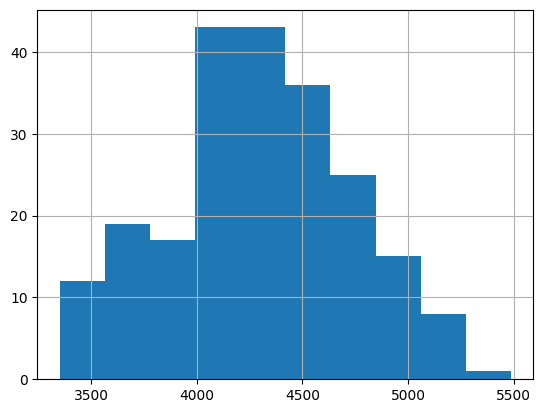

In [ ]:
tt = pd.Series(trainer.train_dataset['attention_mask'])
tt = tt.map(lambda x : len(x))
tt.hist()

In [ ]:
from unsloth.chat_templates import train_on_responses_only

response_trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|turn>user\n",
    response_part = "<|turn>model\n",
)

Map (num_proc=16):   0%|          | 0/219 [00:00<?, ? examples/s]

Filter (num_proc=16):   0%|          | 0/219 [00:00<?, ? examples/s]

In [ ]:
labels = response_trainer.train_dataset[0]['labels']
non_masked_tokens = [l for l in labels if l != -100]
print(f"Total tokens: {len(labels)}")
print(f"Trainable tokens: {len(non_masked_tokens)}")

Total tokens: 4378
Trainable tokens: 215


In [ ]:
response_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 219 | Num Epochs = 4 | Total steps = 112
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 25,337,856 of 5,148,515,872 (0.49% trained)
Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,2.891351
2,2.923002
3,2.766591
4,2.784377
5,2.656669
6,2.406028
7,2.561441
8,2.482694
9,2.386956
10,2.270522


Unsloth: Restored added_tokens_decoder metadata in ./outputs/checkpoint-112/tokenizer_config.json.


TrainOutput(global_step=112, training_loss=1.7698254712990351, metrics={'train_runtime': 3758.0133, 'train_samples_per_second': 0.233, 'train_steps_per_second': 0.03, 'total_flos': 5.730748345951104e+16, 'train_loss': 1.7698254712990351, 'epoch': 4.0})

In [ ]:
from google.colab import drive, userdata

repo_id = "sookiemonster/gemma-4-asrs-increment-2-response-only"
model.push_to_hub(repo_id, token=userdata.get('HF_TOKEN'))
tokenizer.push_to_hub(repo_id, token=userdata.get('HF_TOKEN'))

README.md:   0%|          | 0.00/575 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   1%|          |  558kB /  101MB            

Saved model to https://huggingface.co/sookiemonster/gemma-4-asrs-increment-2-response-only


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp8tv4w9ih/tokenizer_config.json.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp8tv4w9ih/tokenizer.json: 100%|##########| 32.2MB / 32.2MB            